In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

np.random.seed(42)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)


# Boosting models
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

import shap
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Data Loading and Initial Exploration

In [2]:
# Load the dataset
data_path = Path('../assets/data/airline_transport.csv')
df = pd.read_csv(data_path)

print("=== DATASET OVERVIEW ===")
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n=== FIRST 5 ROWS ===")
display(df.head())

=== DATASET OVERVIEW ===
Dataset shape: (103904, 24)
Memory usage: 49.77 MB

=== FIRST 5 ROWS ===


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
# Basic info about the dataset
print("=== DATASET INFO ===")
df.info()

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe(include='all').T)

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,NaN,NaN,NaN,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0


In [4]:
df['satisfaction'].head()

0    neutral or dissatisfied
1    neutral or dissatisfied
2                  satisfied
3    neutral or dissatisfied
4                  satisfied
Name: satisfaction, dtype: object

In [5]:
# Check target variable format and standardize 
print("=== TARGET VARIABLE ANALYSIS ===")
print(f"Target column 'satisfaction' unique values: {df['satisfaction'].unique()}")
print(f"Target value counts:\n{df['satisfaction'].value_counts()}")

# Standardize target to {0,1} if needed
if df['satisfaction'].dtype == 'object':
    print("\nConverting text target to binary...")
    df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
    print(f"After conversion: {df['satisfaction'].unique()}")

# set target is integer
df['satisfaction'] = df['satisfaction'].astype(int)

# Check for missing values in target
print(f"\nMissing values in target: {df['satisfaction'].isna().sum()}")
print(f"Final target distribution:\n{df['satisfaction'].value_counts()}")

=== TARGET VARIABLE ANALYSIS ===
Target column 'satisfaction' unique values: ['neutral or dissatisfied' 'satisfied']
Target value counts:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

Converting text target to binary...
After conversion: [0 1]

Missing values in target: 0
Final target distribution:
satisfaction
0    58879
1    45025
Name: count, dtype: int64


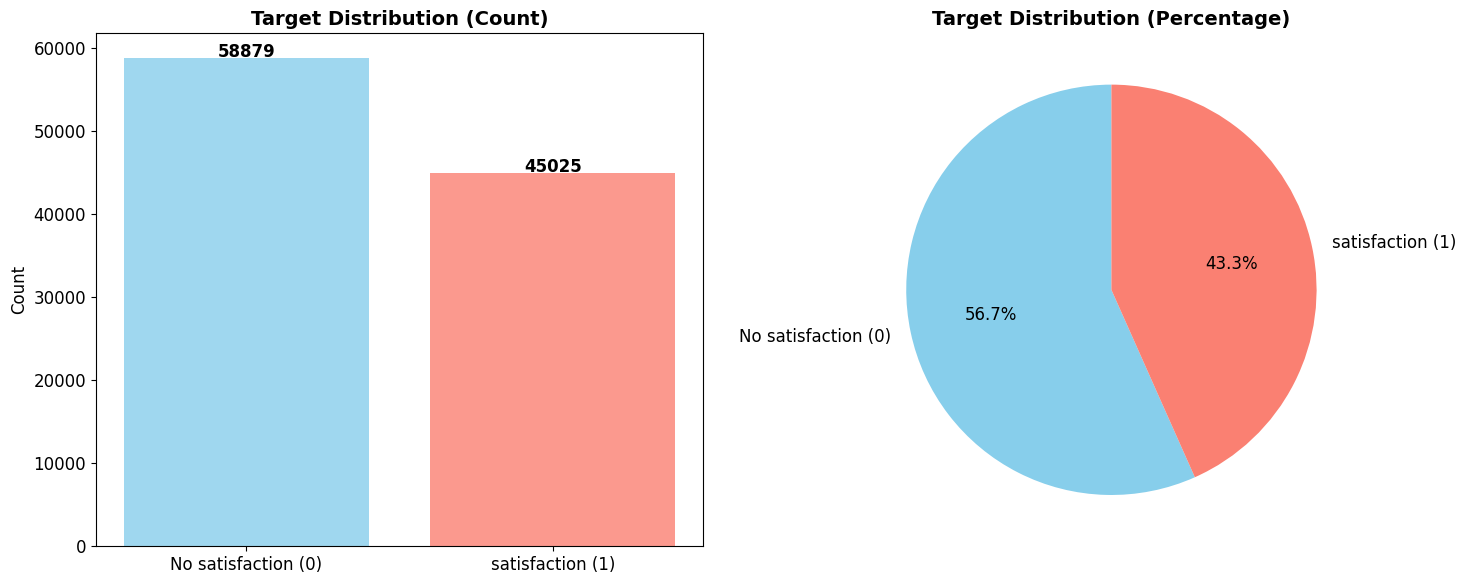


=== IMBALANCE ANALYSIS ===
Majority class (No satisfaction): 58,879 samples (56.7%)
Minority class (satisfaction): 45,025 samples (43.3%)
Imbalance ratio (majority/minority): 1.31:1
This is a imbalanced dataset


In [6]:
# Target distribution analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
target_counts = df['satisfaction'].value_counts()
ax1.bar(['No satisfaction (0)', 'satisfaction (1)'], target_counts.values, 
        color=['skyblue', 'salmon'], alpha=0.8)
ax1.set_title('Target Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')
    
# Pie chart
ax2.pie(target_counts.values, labels=['No satisfaction (0)', 'satisfaction (1)'], 
        autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
ax2.set_title('Target Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate imbalance metrics
n_majority = target_counts[0]
n_minority = target_counts[1]
imbalance_ratio = n_majority / n_minority

print(f"\n=== IMBALANCE ANALYSIS ===")
print(f"Majority class (No satisfaction): {n_majority:,} samples ({n_majority/len(df)*100:.1f}%)")
print(f"Minority class (satisfaction): {n_minority:,} samples ({n_minority/len(df)*100:.1f}%)")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")
print(f"This is a {'highly ' if imbalance_ratio > 5 else ''}imbalanced dataset")

In [7]:
# Analyze feature types
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric if present
if 'satisfaction' in numeric_features:
    numeric_features.remove('satisfaction')


print("=== FEATURE TYPES ANALYSIS ===")
print(f"Total features: {len(df.columns) - 1}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Store that we will use later
feature_types = {
    'numeric': numeric_features,
    'categorical': categorical_features,
}

=== FEATURE TYPES ANALYSIS ===
Total features: 23
Numeric features (19): ['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical features (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [8]:
# Update feature type lists after dropping customerID
categorical_features = [col for col in categorical_features if col in df.columns]
id_columns = []  # Clear since we dropped customerID

print("=== UPDATED FEATURE TYPES ===")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"ID columns ({len(id_columns)}): {id_columns}")
print(f"\\nTotal features for modeling: {len(numeric_features) + len(categorical_features)}")

=== UPDATED FEATURE TYPES ===
Numeric features (19): ['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical features (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']
ID columns (0): []
\nTotal features for modeling: 23


## Numeric Features Analysis

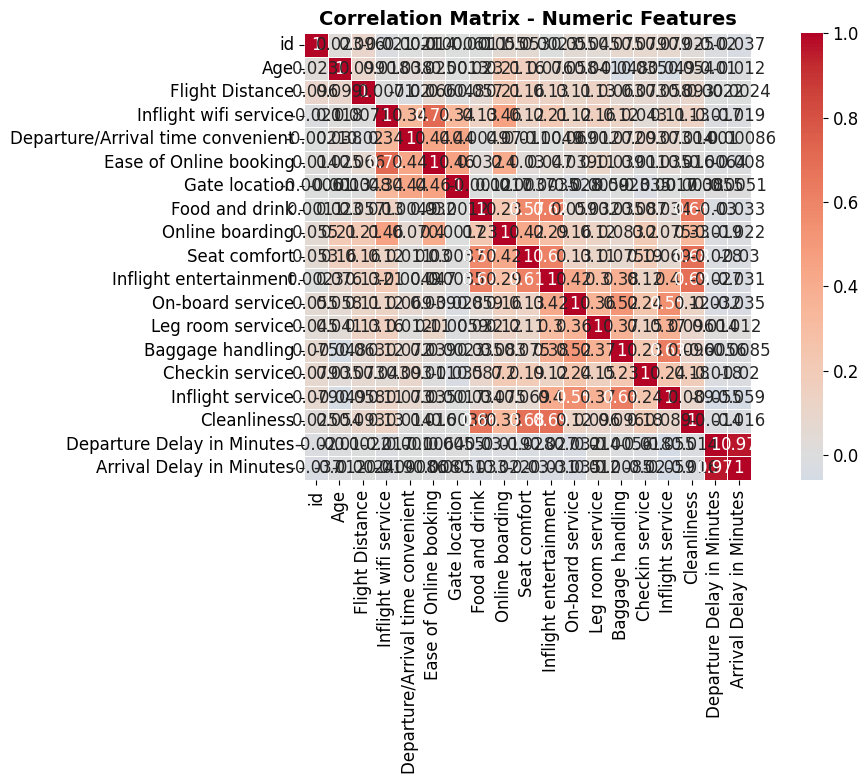


=== TOP CORRELATIONS ===
Departure Delay in Minutes <-> Arrival Delay in Minutes: 0.965
Inflight wifi service <-> Ease of Online booking: 0.716
Inflight entertainment <-> Cleanliness: 0.692
Seat comfort <-> Cleanliness: 0.679
Food and drink <-> Cleanliness: 0.658


In [9]:
# Numeric features correlation heatmap
if len(numeric_features) > 1:
    plt.figure(figsize=(12, 8))
    correlation_matrix = df[numeric_features].corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Let's see highest correlations:
    corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))
    
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    print("\n=== TOP CORRELATIONS ===")
    for feat1, feat2, corr in corr_pairs[:5]:
        print(f"{feat1} <-> {feat2}: {corr:.3f}")

In [10]:
# Analyze categorical features
print(" CATEGORICAL FEATURES SUMMARY ")
for feature in categorical_features[:10]:  # Show first 10 
    unique_count = df[feature].nunique()
    print(f"{feature}: {unique_count} unique values")
    if unique_count <= 10:
        print(f"  Values: {list(df[feature].unique())}")
    print()

 CATEGORICAL FEATURES SUMMARY 
Gender: 2 unique values
  Values: ['Male', 'Female']

Customer Type: 2 unique values
  Values: ['Loyal Customer', 'disloyal Customer']

Type of Travel: 2 unique values
  Values: ['Personal Travel', 'Business travel']

Class: 3 unique values
  Values: ['Eco Plus', 'Business', 'Eco']



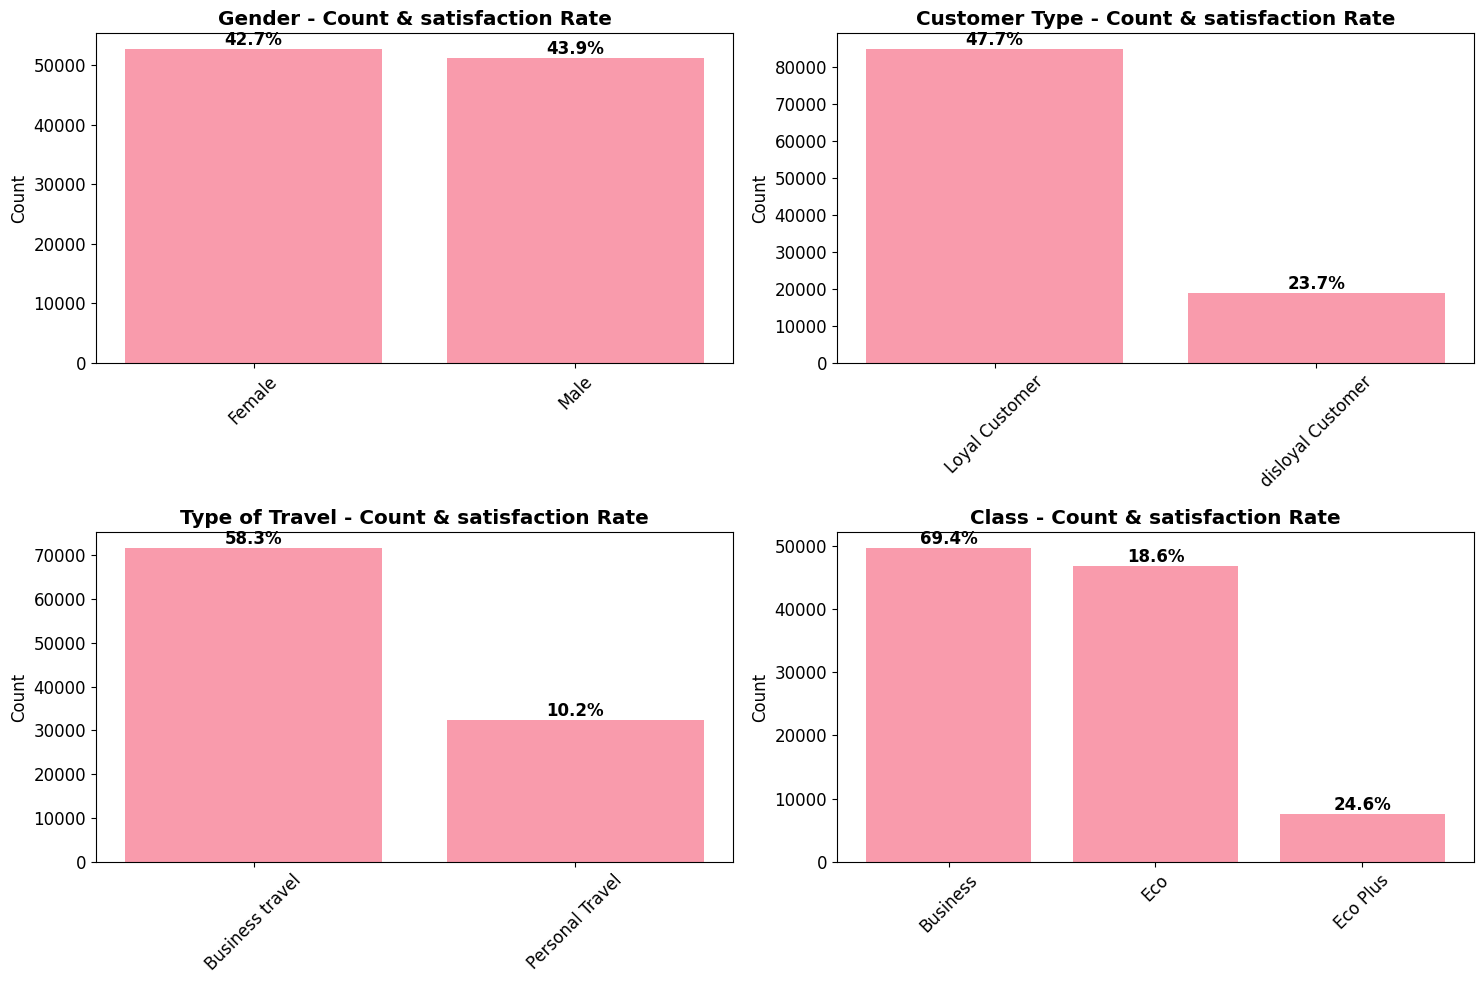

In [11]:
# Visualize key categorical features
key_categorical = [col for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']
                   if col in categorical_features or col in numeric_features]

if len(key_categorical) > 0:
    n_cols = 2
    n_rows = (len(key_categorical) + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for i, feature in enumerate(key_categorical):
        if i < len(axes):
            # Count plot with churn rate
            df_temp = df.groupby(feature)['satisfaction'].agg(['count', 'mean']).reset_index()
            
            ax = axes[i]
            bars = ax.bar(df_temp[feature], df_temp['count'], alpha=0.7)
            
            # Add churn rate as text on bars
            for j, (bar, churn_rate) in enumerate(zip(bars, df_temp['mean'])):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                       f'{churn_rate:.1%}', ha='center', va='bottom', fontweight='bold')
            
            ax.set_title(f'{feature} - Count & satisfaction Rate', fontweight='bold')
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for i in range(len(key_categorical), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 8. Data Quality Assessment & Summary

In [12]:
# Final data quality summary
print(" DATA QUALITY SUMMARY ")
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Target distribution: {df['satisfaction'].value_counts().to_dict()}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

print(f"\n✅ Data preprocessing completed - Ready for model training")

 DATA QUALITY SUMMARY 
Dataset shape: (103904, 24)
Missing values: 310
Duplicate rows: 0
Target distribution: {0: 58879, 1: 45025}
Imbalance ratio: 1.31:1

✅ Data preprocessing completed - Ready for model training


# Data Cleaning & Type Fixes

In [13]:
# Handle duplicate rows
print(" HANDLING DUPLICATE ROWS")
print(f"Duplicate rows found: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    # Show some examples of duplicates
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    print(f"\\n Example duplicate rows (first 5):")
    print(duplicate_rows.head())
    
    # Remove duplicates, keeping the first occurrence
    df_before = df.shape[0]
    df = df.drop_duplicates()
    df_after = df.shape[0]
    
    print(f"\\nRemoved {df_before - df_after} duplicate rows")
    print(f"Dataset shape after deduplication: {df.shape}")
    
    # Check target distribution after removing duplicates
    print(f"Target distribution after deduplication: {df['Revenue'].value_counts().to_dict()}")
    
    # Update imbalance ratio
    n_majority = (df['satisfaction'] == 0).sum()
    n_minority = (df['satisfaction'] == 1).sum()
    imbalance_ratio = n_majority / n_minority
    print(f"Updated imbalance ratio: {imbalance_ratio:.2f}:1")
else:
    print("No duplicate rows found.")

 HANDLING DUPLICATE ROWS
Duplicate rows found: 0
No duplicate rows found.


# Train/Test Split

In [14]:
# Stratified train/test split
print(" TRAIN/TEST SPLIT ")

# Separate features and target
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples ({y_train.value_counts()[0]:,} no satisfaction, {y_train.value_counts()[1]:,} satisfaction)")
print(f"Test set: {X_test.shape[0]:,} samples ({y_test.value_counts()[0]:,} no satisfaction, {y_test.value_counts()[1]:,} satisfaction)")

# Calculate final imbalance ratio on training set
train_imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Training set imbalance ratio: {train_imbalance_ratio:.2f}:1")

 TRAIN/TEST SPLIT 
Training set: 83,123 samples (47,103 no satisfaction, 36,020 satisfaction)
Test set: 20,781 samples (11,776 no satisfaction, 9,005 satisfaction)
Training set imbalance ratio: 1.31:1


# Preprocessing Strategy

In [15]:
# Define categorical indices for CatBoost (native categorical handling)
print(" CATBOOST PREPROCESSING SETUP ")

# Create categorical indices based on X_train column order
cat_indices = []
feature_names = list(X_train.columns)

for i, col in enumerate(feature_names):
    if col in categorical_features:
        cat_indices.append(i)

print(f"Feature order in X_train: {feature_names}")
print(f"Categorical feature indices for CatBoost: {cat_indices}")
print(f"Categorical features: {[feature_names[i] for i in cat_indices]}")

# Verify the mapping
print("\\nCategorical feature mapping:")
for idx in cat_indices:
    print(f"  Index {idx}: {feature_names[idx]}")

print(f"\\nNumeric features for CatBoost: {[col for col in feature_names if col not in categorical_features]}")

 CATBOOST PREPROCESSING SETUP 
Feature order in X_train: ['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical feature indices for CatBoost: [1, 2, 4, 5]
Categorical features: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
\nCategorical feature mapping:
  Index 1: Gender
  Index 2: Customer Type
  Index 4: Type of Travel
  Index 5: Class
\nNumeric features for CatBoost: ['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', '

In [16]:
# Create ColumnTransformer for XGBoost (One-Hot encoding)
print("=== XGBoost PREPROCESSING SETUP ===")

# Define preprocessor with One-Hot encoding for categoricals and passthrough for numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

print(f"Numeric features for passthrough: {numeric_features}")
print(f"Categorical features for OneHot encoding: {categorical_features}")

# Fit the preprocessor on training data to see the output
print("\\nFitting preprocessor on training data...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
print(f"Original X_train shape: {X_train.shape}")
print(f"Preprocessed X_train shape: {X_train_preprocessed.shape}")

# Get feature names after preprocessing
try:
    feature_names_preprocessed = preprocessor.get_feature_names_out()
except AttributeError:
    # if any problem with sklearn try this:
    numeric_names = numeric_features
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_names = cat_encoder.get_feature_names(categorical_features)
    feature_names_preprocessed = numeric_names + list(cat_names)

print(f"Number of features after preprocessing: {len(feature_names_preprocessed)}")
print(f"First 10 feature names: {feature_names_preprocessed[:10]}")
print(f"Last 10 feature names: {feature_names_preprocessed[-10:]}")

=== XGBoost PREPROCESSING SETUP ===
Numeric features for passthrough: ['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical features for OneHot encoding: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
\nFitting preprocessor on training data...
Original X_train shape: (83123, 23)
Preprocessed X_train shape: (83123, 28)
Number of features after preprocessing: 28
First 10 feature names: ['num__id' 'num__Age' 'num__Flight Distance' 'num__Inflight wifi service'
 'num__Departure/Arrival time convenient' 'num__Ease of Online booking'
 'num__Gate location' 'num__Food and drink' 'num__Online boarding'
 'num__Seat comfort']
Last 10 feature names: 

In [17]:
# Compute class imbalance metrics and setup class weights

# Calculate class distribution
class_counts = y_train.value_counts().sort_index()
n_samples = len(y_train)
n_classes = len(class_counts)

print(f"Training set class distribution:")
for class_label, count in class_counts.items():
    percentage = count / n_samples * 100
    print(f"  Class {class_label}: {count:,} samples ({percentage:.1f}%)")

# Calculate imbalance ratio
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")

class_weights_balanced = n_samples / (n_classes * class_counts)
print(f"\\nBalanced class weights:")
for class_label, weight in class_weights_balanced.items():
    print(f"  Class {class_label}: {weight:.3f}")

scale_pos_weight = class_counts[0] / class_counts[1]
print(f"\\nXGBoost scale_pos_weight: {scale_pos_weight:.3f}")

total_neg = class_counts[0]
total_pos = class_counts[1]
catboost_class_weights = [1.0, total_neg / total_pos]
print(f"CatBoost class weights [neg, pos]: {catboost_class_weights}")

# Store class weight configurations
class_weight_configs = {
    'balanced_weights': class_weights_balanced,
    'scale_pos_weight': scale_pos_weight,
    'catboost_weights': catboost_class_weights
}

print(f"\\n Class weight configurations ready for all models")

Training set class distribution:
  Class 0: 47,103 samples (56.7%)
  Class 1: 36,020 samples (43.3%)
\nImbalance ratio (majority/minority): 1.31:1
\nBalanced class weights:
  Class 0: 0.882
  Class 1: 1.154
\nXGBoost scale_pos_weight: 1.308
CatBoost class weights [neg, pos]: [1.0, 1.3076901721265963]
\n Class weight configurations ready for all models


#  Imbalance Handling & Model Setup

## Hyperparameter Grids 


In [18]:
# Helper function to calculate grid size
def calculate_grid_size(param_grid):
    total = 1
    for values in param_grid.values():
        total *= len(values)
    return total

# XGBoost Hyperparameter Grid (Fast Version)
print(" XGBOOST HYPERPARAMETER GRID ")

xgb_param_grid = {
    "n_estimators":       [200, 400, 600],
    "learning_rate":      [0.05, 0.1, 0.4],
    "max_depth":          [3, 6, 9],
    "scale_pos_weight":   [1, scale_pos_weight]
}

grid_size = calculate_grid_size(xgb_param_grid)
print(f"XGBoost grid: {grid_size} combinations ({grid_size * 5} CV fits)")
print(f"Hyperparameter ranges:")
print(f"  • n_estimators: {xgb_param_grid['n_estimators']}")
print(f"  • learning_rate: {xgb_param_grid['learning_rate']}")
print(f"  • max_depth: {xgb_param_grid['max_depth']}")
print(f"  • scale_pos_weight: [1, {scale_pos_weight:.3f}]")

 XGBOOST HYPERPARAMETER GRID 
XGBoost grid: 54 combinations (270 CV fits)
Hyperparameter ranges:
  • n_estimators: [200, 400, 600]
  • learning_rate: [0.05, 0.1, 0.4]
  • max_depth: [3, 6, 9]
  • scale_pos_weight: [1, 1.308]


In [19]:
# CatBoost Hyperparameter Grid (Fast Version)
print(" CATBOOST HYPERPARAMETER GRID ")

cat_param_grid = {
    "iterations":        [200, 500, 1000],
    "learning_rate":     [0.05, 0.1, 0.4],
    "depth":             [4, 6, 9],
    "class_weights":     [None, catboost_class_weights]
}

grid_size = calculate_grid_size(cat_param_grid)
print(f"CatBoost grid: {grid_size} combinations ({grid_size * 5} CV fits)")
print(f"Hyperparameter ranges:")
print(f"  • iterations: {cat_param_grid['iterations']}")
print(f"  • learning_rate: {cat_param_grid['learning_rate']}")
print(f"  • depth: {cat_param_grid['depth']}")
print(f"  • class_weights: [None, {catboost_class_weights}]")

total_combinations = calculate_grid_size(xgb_param_grid) + calculate_grid_size(cat_param_grid)
print(f"\nTotal across all models: {total_combinations} combinations")

 CATBOOST HYPERPARAMETER GRID 
CatBoost grid: 54 combinations (270 CV fits)
Hyperparameter ranges:
  • iterations: [200, 500, 1000]
  • learning_rate: [0.05, 0.1, 0.4]
  • depth: [4, 6, 9]
  • class_weights: [None, [1.0, 1.3076901721265963]]

Total across all models: 108 combinations


In [20]:
# Setup StratifiedKFold Cross-Validation
print(" CROSS-VALIDATION SETUP ")

# Initialize StratifiedKFold 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Cross-validation strategy: StratifiedKFold")
print(f"Number of folds: {cv_strategy.n_splits}")
print(f"Shuffle: {cv_strategy.shuffle}")
print(f"Random state: {cv_strategy.random_state}")

# Test the CV strategy
print(f"\\nTesting CV splits on training data:")
split_info = []
for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train), 1):
    train_dist = y_train.iloc[train_idx].value_counts().sort_index()
    val_dist = y_train.iloc[val_idx].value_counts().sort_index()
    
    train_prop = train_dist / len(train_idx)
    val_prop = val_dist / len(val_idx)
    
    split_info.append({
        'fold': fold,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'train_prop_0': train_prop[0],
        'train_prop_1': train_prop[1],
        'val_prop_0': val_prop[0],
        'val_prop_1': val_prop[1]
    })
    
    print(f"Fold {fold}: Train={len(train_idx)}, Val={len(val_idx)}")
    print(f"  Train proportions: {train_prop.round(3).to_dict()}")
    print(f"  Val proportions: {val_prop.round(3).to_dict()}")

print(f"\\n Stratified CV maintains class balance across all folds")

# Common GridSearchCV parameters
cv_params = {
    'cv': cv_strategy,
    'scoring': 'roc_auc',
    'n_jobs': -1,
    'refit': True,
    'verbose': 1
}

print(f"\\nGridSearchCV configuration:")
for param, value in cv_params.items():
    print(f"  {param}: {value}")

 CROSS-VALIDATION SETUP 
Cross-validation strategy: StratifiedKFold
Number of folds: 5
Shuffle: True
Random state: 42
\nTesting CV splits on training data:
Fold 1: Train=66498, Val=16625
  Train proportions: {0: 0.567, 1: 0.433}
  Val proportions: {0: 0.567, 1: 0.433}
Fold 2: Train=66498, Val=16625
  Train proportions: {0: 0.567, 1: 0.433}
  Val proportions: {0: 0.567, 1: 0.433}
Fold 3: Train=66498, Val=16625
  Train proportions: {0: 0.567, 1: 0.433}
  Val proportions: {0: 0.567, 1: 0.433}
Fold 4: Train=66499, Val=16624
  Train proportions: {0: 0.567, 1: 0.433}
  Val proportions: {0: 0.567, 1: 0.433}
Fold 5: Train=66499, Val=16624
  Train proportions: {0: 0.567, 1: 0.433}
  Val proportions: {0: 0.567, 1: 0.433}
\n Stratified CV maintains class balance across all folds
\nGridSearchCV configuration:
  cv: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
  scoring: roc_auc
  n_jobs: -1
  refit: True
  verbose: 1


## Model Setup 

In [21]:
# Setup Base Model Estimators
print(" BASE MODEL ESTIMATORS SETUP ")

# XGBoost Estimator (for One-Hot encoded data)
xgb_estimator = XGBClassifier(
    tree_method='hist',
    eval_metric='auc', 
    random_state=42,
    n_jobs=-1
)

# CatBoost Estimator (for native categorical data)
cat_estimator = CatBoostClassifier(
    verbose=False,
    random_state=42,
    loss_function="Logloss",
    eval_metric="AUC",
)

print("Base estimators created:")
print(f"  XGBoost: {type(xgb_estimator).__name__}")
print(f"  CatBoost: {type(cat_estimator).__name__}")

# Prepare parameter grids with auto-replacement for scale_pos_weight
print(f"\\nPreparing parameter grids...")

# Replace "auto" with calculated value in XGBoost grid
xgb_param_grid_processed = xgb_param_grid.copy()
xgb_param_grid_processed["scale_pos_weight"] = [
    scale_pos_weight if x == "auto" else x 
    for x in xgb_param_grid["scale_pos_weight"]
]

# Replace "auto" with calculated weights in CatBoost grid
cat_param_grid_processed = cat_param_grid.copy()
cat_param_grid_processed["class_weights"] = [
    catboost_class_weights if x == "auto" else x 
    for x in cat_param_grid["class_weights"]
]

print(f" Parameter grids processed:")
print(f"  XGBoost scale_pos_weight values: {xgb_param_grid_processed['scale_pos_weight']}")
print(f"  CatBoost class_weights values: {cat_param_grid_processed['class_weights']}")

 BASE MODEL ESTIMATORS SETUP 
Base estimators created:
  XGBoost: XGBClassifier
  CatBoost: CatBoostClassifier
\nPreparing parameter grids...
 Parameter grids processed:
  XGBoost scale_pos_weight values: [1, 1.3076901721265963]
  CatBoost class_weights values: [None, [1.0, 1.3076901721265963]]


# Model Training & Hyperparameter Optimization

## GridSearchCV Execution

In [22]:

def train_and_store_model(name, estimator, param_grid, X_data, y_data, cat_features=None):
    """Train model with GridSearchCV and store results"""
    import time
    
    start_time = time.time()
    
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        **cv_params
    )
    
    print(f"Training {name}...")
    if cat_features is not None:
        grid_search.fit(X_data, y_data, cat_features=cat_features)
    else:
        grid_search.fit(X_data, y_data)
    
    training_time = time.time() - start_time
    
    print(f" {name} completed! Time: {training_time:.1f}s, Best ROC-AUC: {grid_search.best_score_:.4f}")
    
    return {
        'model': grid_search.best_estimator_,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'training_time': training_time,
        'cv_results': grid_search.cv_results_
    }

print(" BRANCH A: MODEL TRAINING ")

xgb_baseline_results = train_and_store_model(
    "XGBoost (Class Weights)", 
    xgb_estimator, 
    xgb_param_grid, 
    X_train_preprocessed, 
    y_train
)

 BRANCH A: MODEL TRAINING 
Training XGBoost (Class Weights)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
 XGBoost (Class Weights) completed! Time: 183.3s, Best ROC-AUC: 0.9955


In [23]:
# CatBoost Training
cat_baseline_results = train_and_store_model(
    "CatBoost (Class Weights)", 
    cat_estimator, 
    cat_param_grid, 
    X_train, 
    y_train, 
    cat_features=cat_indices
)

Training CatBoost (Class Weights)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
 CatBoost (Class Weights) completed! Time: 1926.8s, Best ROC-AUC: 0.9957


# Evaluation & Model Comparison 

Now that we have trained all our models, let's evaluate their performance on the test set and conduct a comprehensive comparison.

## Test Set Evaluation

Let's evaluate all our trained models on the test set to get unbiased performance metrics.

In [24]:
# Utility function for test evaluation
def evaluate_model_on_test(model_name, model, X_test_data, y_test_data, is_pipeline=False, is_catboost=False):
    """Evaluate model on test set and return metrics"""
    
    # Predict probabilities
    if is_catboost:
        y_pred_proba = model.predict_proba(X_test_data)[:, 1]
    elif is_pipeline:
        y_pred_proba = model.predict_proba(X_test_data)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test_data)[:, 1]
    
    # Generate binary predictions
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calculate metrics
    return {
        'model_name': model_name,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'roc_auc': roc_auc_score(y_test_data, y_pred_proba),
        'precision': precision_score(y_test_data, y_pred),
        'recall': recall_score(y_test_data, y_pred),
        'f1_score': f1_score(y_test_data, y_pred),
        'accuracy': accuracy_score(y_test_data, y_pred)
    }

# Generate test set predictions for all models
print(" GENERATING TEST SET PREDICTIONS")
print("=" * 50)

test_results = {}

# Branch A models with their CV scores, branch info, and best params
models_to_evaluate = [
    ("XGBoost_Baseline", xgb_baseline_results['model'], "A (Class Weights)", xgb_baseline_results['best_score'], xgb_baseline_results['best_params']),
    
    ("CatBoost_Baseline", cat_baseline_results['model'], "A (Class Weights)", cat_baseline_results['best_score'], cat_baseline_results['best_params']),
]

for model_name, model, branch, cv_score, best_params in models_to_evaluate:
    # Determine correct test data format
    if model_name in ["XGBoost_Baseline"]:
        test_data = preprocessor.transform(X_test)
        is_pipeline = False
        is_catboost = False
    elif model_name == "CatBoost_Baseline":
        test_data = X_test
        is_pipeline = False
        is_catboost = True
        
    results = evaluate_model_on_test(model_name, model, test_data, y_test, is_pipeline, is_catboost)
    
    # Add branch, CV score, and best params information
    results['branch'] = branch
    results['cv_score'] = cv_score
    results['best_params'] = best_params
    
    test_results[model_name] = results
    
    print(f"{model_name:<20} | AUC: {results['roc_auc']:.3f} | Precision: {results['precision']:.3f} | Recall: {results['recall']:.3f}")

print(f"\n Test evaluation completed for {len(test_results)} models!")

 GENERATING TEST SET PREDICTIONS
XGBoost_Baseline     | AUC: 0.996 | Precision: 0.965 | Recall: 0.954
CatBoost_Baseline    | AUC: 0.996 | Precision: 0.965 | Recall: 0.957

 Test evaluation completed for 2 models!


In [25]:
# Create comprehensive model comparison table
import pandas as pd

print(" Comprehensive Model Comparison")
print("=" * 50)

# Create comparison dataframe
comparison_data = []

for model_name, results in test_results.items():
    comparison_data.append({
        'Model': model_name,
        'CV ROC-AUC': results['cv_score'],
        'Test ROC-AUC': results['roc_auc'],
        'Test Precision': results['precision'],
        'Test Recall': results['recall'],
        'Test F1-Score': results['f1_score'],
        'Test Accuracy': results['accuracy']
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort by Test ROC-AUC (primary metric)
comparison_df = comparison_df.sort_values('Test ROC-AUC', ascending=False)

# Display the table
print("\n Model Performance Ranking (sorted by Test ROC-AUC):")
print(comparison_df.round(4).to_string(index=False))

# Find the best model
best_model_idx = comparison_df.index[0]
best_model_name = comparison_df.iloc[0]['Model']
best_test_auc = comparison_df.iloc[0]['Test ROC-AUC']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Test ROC-AUC: {best_test_auc:.4f}")

# Performance summary by branch
print(f"\n Branch Performance Summary:")
branch_summary = comparison_df.groupby('Model').agg({
    'Test ROC-AUC': ['mean', 'max', 'min'],
    'Test Recall': ['mean', 'max', 'min']
}).round(4)

print(branch_summary)

# Check our metrics
print(f"\n  Metrics Assessment:")
print(f"   ROC-AUC ≥ 0.80: {'✅' if best_test_auc >= 0.80 else '❌'} (Best: {best_test_auc:.4f})")

# Find best recall model
best_recall_idx = comparison_df['Test Recall'].idxmax()
best_recall_model = comparison_df.loc[best_recall_idx, 'Model']
best_recall_score = comparison_df.loc[best_recall_idx, 'Test Recall']
print(f"   Recall ≥ 0.75: {'✅' if best_recall_score >= 0.75 else '❌'} (Best: {best_recall_score:.4f} - {best_recall_model})")

# Save comparison results
comparison_df.to_csv('../data/model_comparison_results.csv', index=False)
print(f"\n Comparison results saved to '../data/model_comparison_results.csv'")

 Comprehensive Model Comparison

 Model Performance Ranking (sorted by Test ROC-AUC):
            Model  CV ROC-AUC  Test ROC-AUC  Test Precision  Test Recall  Test F1-Score  Test Accuracy
CatBoost_Baseline      0.9957        0.9960          0.9650       0.9570         0.9610         0.9663
 XGBoost_Baseline      0.9955        0.9958          0.9652       0.9536         0.9593         0.9650

 BEST MODEL: CatBoost_Baseline
   Test ROC-AUC: 0.9960

 Branch Performance Summary:
                  Test ROC-AUC                 Test Recall                
                          mean     max     min        mean     max     min
Model                                                                     
CatBoost_Baseline       0.9960  0.9960  0.9960      0.9570  0.9570  0.9570
XGBoost_Baseline        0.9958  0.9958  0.9958      0.9536  0.9536  0.9536

  Metrics Assessment:
   ROC-AUC ≥ 0.80: ✅ (Best: 0.9960)
   Recall ≥ 0.75: ✅ (Best: 0.9570 - CatBoost_Baseline)

 Comparison results saved to 

## Visualization & Analysis

Let's create comprehensive visualizations to compare model performance and analyze trade-offs.

 Creating ROC Curves Comparison...


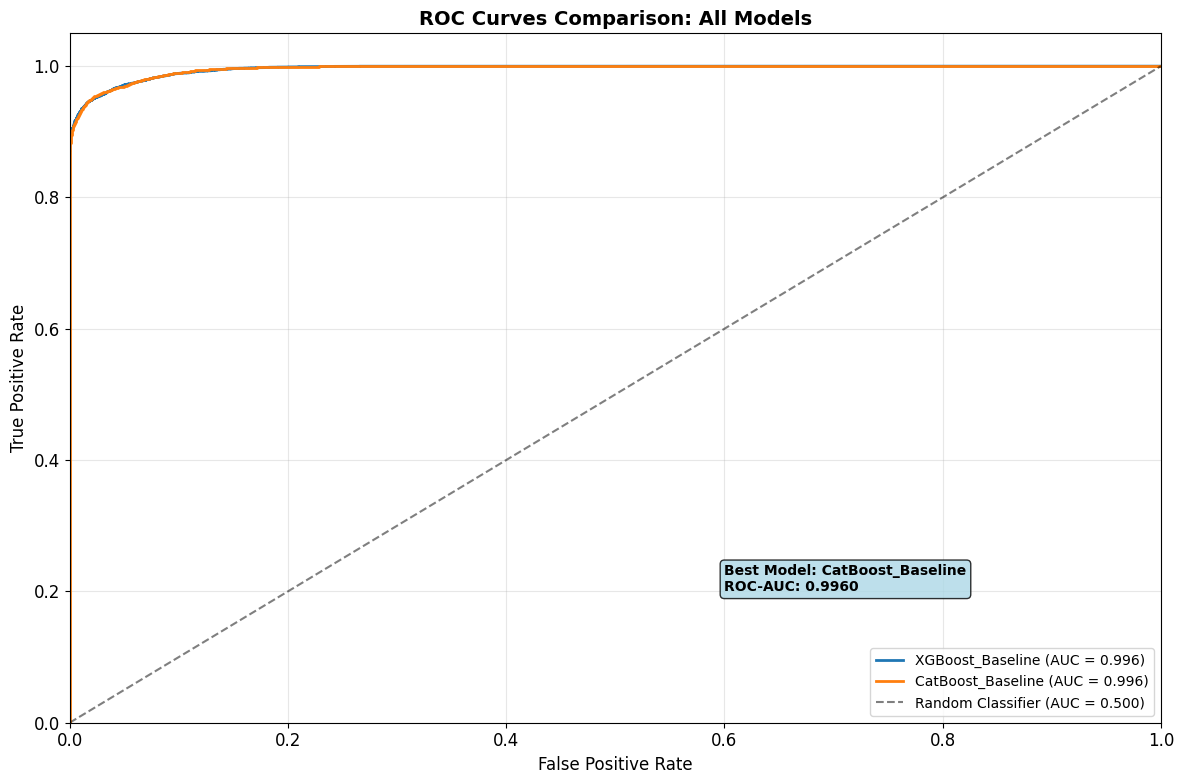

 ROC curves comparison completed!


In [26]:
# ROC Curves Comparison

plt.figure(figsize=(12, 8))

# Define colors and markers for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
linestyles = ['-', '--', '-.', ':', '-']

print(" Creating ROC Curves Comparison...")

# Plot ROC curve for each model
for i, (model_name, results) in enumerate(test_results.items()):
    y_pred_proba = results['y_pred_proba']
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = results['roc_auc']
    
    # Determine line style based on branch
    linestyle = '-'
    label = f"{model_name} (AUC = {roc_auc:.3f})"
    
    plt.plot(fpr, tpr, color=colors[i], linestyle=linestyle, 
             linewidth=2, label=label)

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.500)')

# Customize plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison: All Models', 
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)

# Add annotation for best model
best_model_name = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['Test ROC-AUC']
plt.text(0.6, 0.2, f'Best Model: {best_model_name}\nROC-AUC: {best_auc:.4f}', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
         fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(" ROC curves comparison completed!")

 Creating Confusion Matrix Heatmaps...


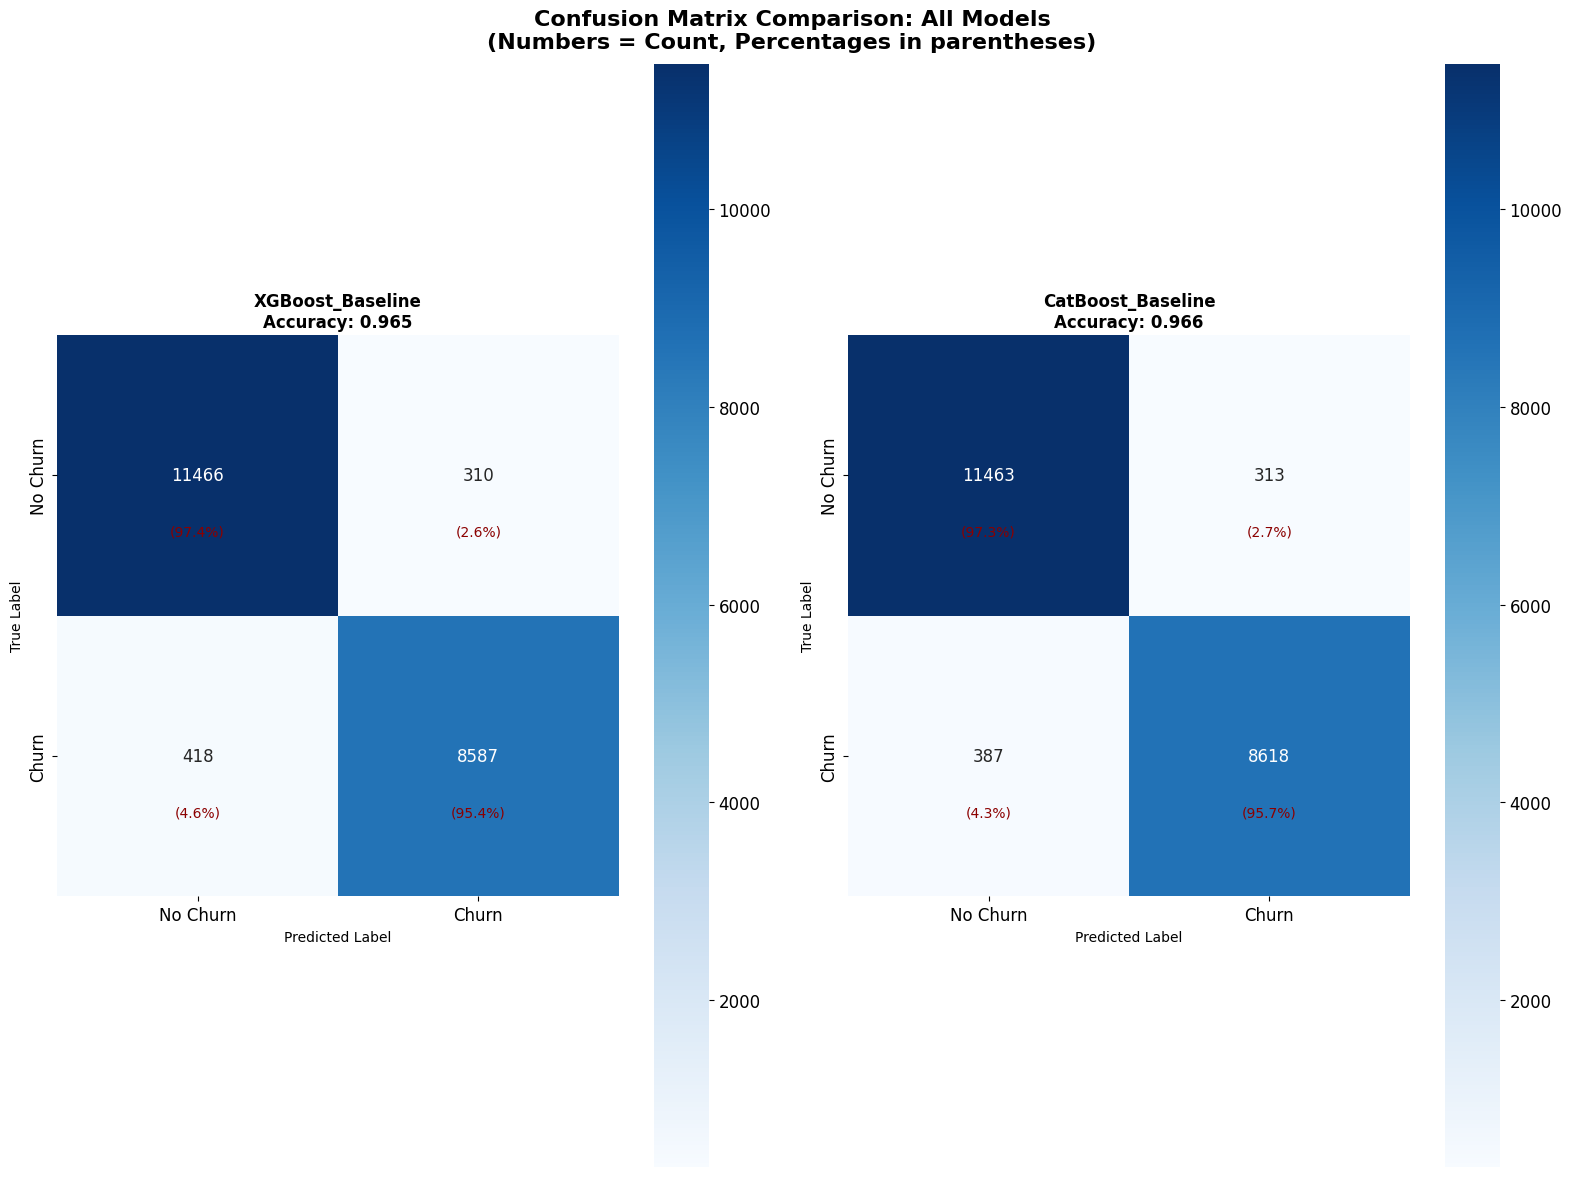


 Confusion Matrix Summary:
Model                TN    FP    FN    TP    Precision  Recall   F1      
----------------------------------------------------------------------
XGBoost_Baseline     11466 310   418   8587  0.965      0.954    0.959   
CatBoost_Baseline    11463 313   387   8618  0.965      0.957    0.961   

Legend: TN=True Negative, FP=False Positive, FN=False Negative, TP=True Positive
 Confusion matrix analysis completed!


In [27]:
# Confusion Matrix Heatmaps

print(" Creating Confusion Matrix Heatmaps...")

# Create subplots for all models
fig, axes = plt.subplots(1, 2, figsize=(16, 12))
axes = axes.flatten()

model_names = list(test_results.keys())

for i, (model_name, results) in enumerate(test_results.items()):
    y_pred = results['y_pred']
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                square=True, ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    
    # Add percentage annotations
    for j in range(2):
        for k in range(2):
            axes[i].text(k+0.5, j+0.7, f'({cm_percent[j,k]:.1%})', 
                        ha='center', va='center', fontsize=10, color='darkred')
    
    # Customize subplot
    axes[i].set_title(f'{model_name}\nAccuracy: {results["accuracy"]:.3f}', 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrix Comparison: All Models\n(Numbers = Count, Percentages in parentheses)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Summary of confusion matrices
print("\n Confusion Matrix Summary:")
print("=" * 70)
print(f"{'Model':<20} {'TN':<5} {'FP':<5} {'FN':<5} {'TP':<5} {'Precision':<10} {'Recall':<8} {'F1':<8}")
print("-" * 70)

for model_name, results in test_results.items():
    cm = confusion_matrix(y_test, results['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    
    print(f"{model_name:<20} {tn:<5} {fp:<5} {fn:<5} {tp:<5} "
          f"{results['precision']:<10.3f} {results['recall']:<8.3f} {results['f1_score']:<8.3f}")

print("\nLegend: TN=True Negative, FP=False Positive, FN=False Negative, TP=True Positive")
print(" Confusion matrix analysis completed!")

 Threshold Tuning Analysis
Analyzing threshold tuning for: CatBoost_Baseline


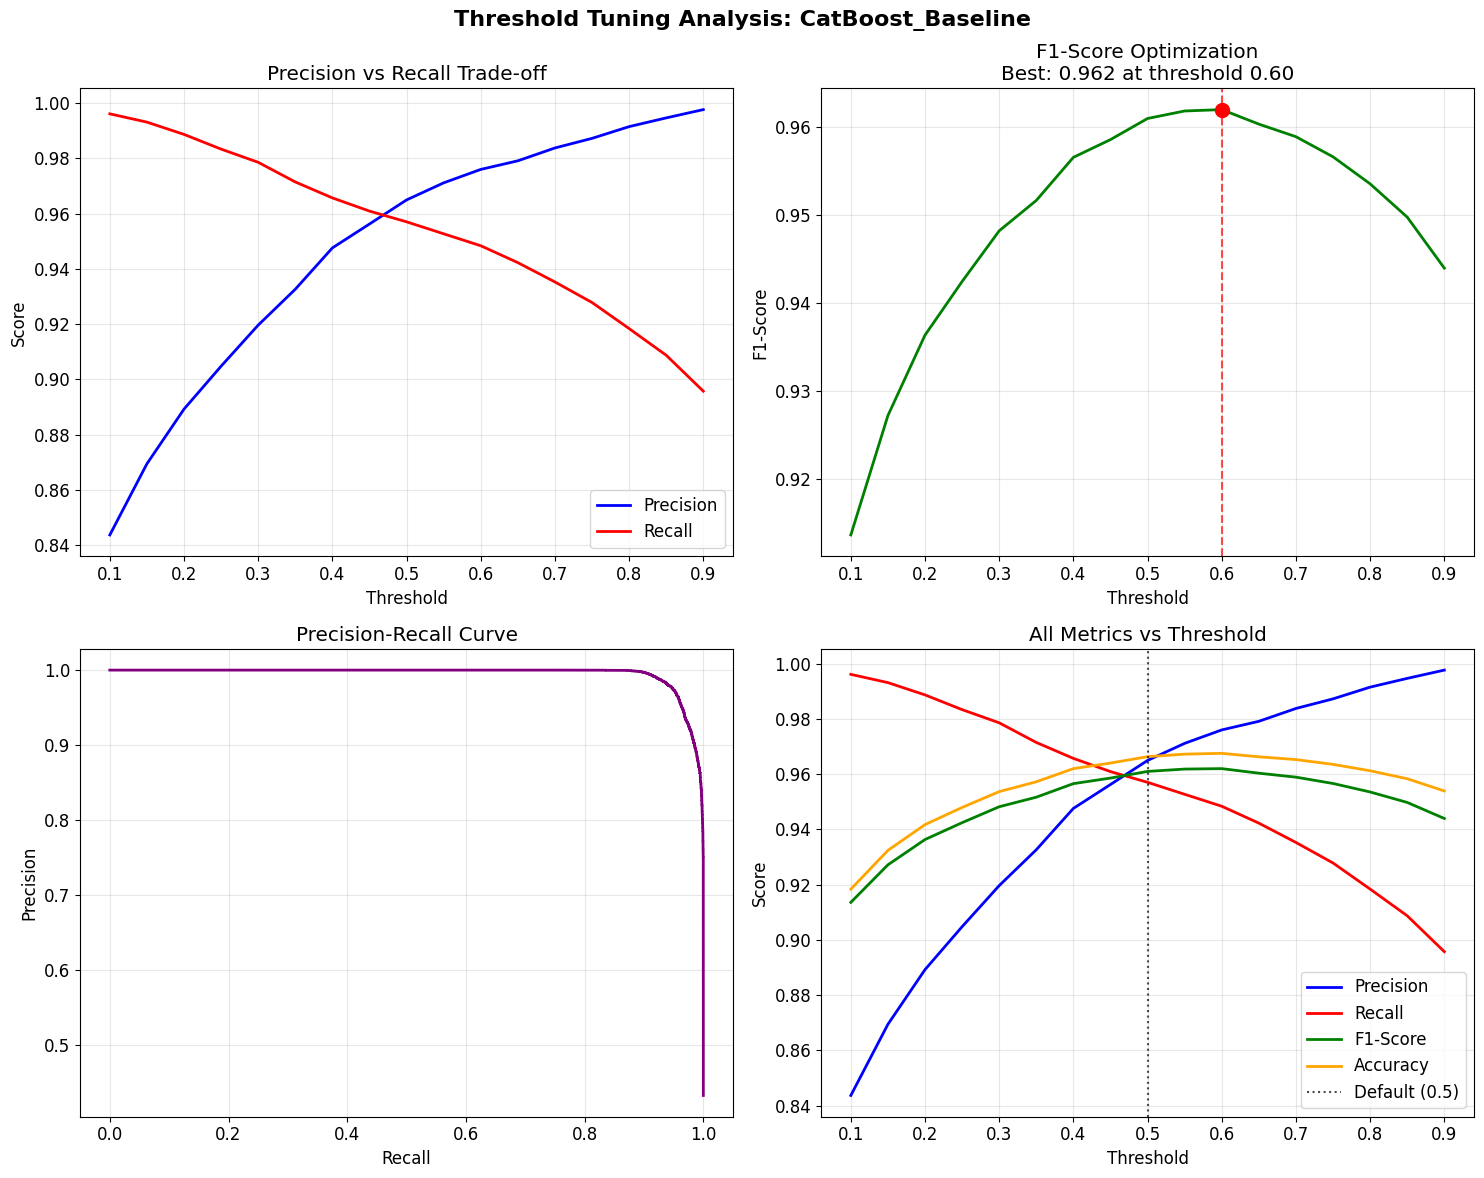


 Threshold Recommendations:
   For optimal F1-Score: 0.60 (F1: 0.962)
   For Recall ≥ 0.75: 0.90 (Recall: 0.75+, Precision: 0.998, F1: 0.944)

 Threshold tuning analysis completed!


In [28]:
# Threshold Tuning Analysis
print(" Threshold Tuning Analysis")
print("=" * 50)

# Use the best model for threshold analysis
best_model_name = comparison_df.iloc[0]['Model']
best_model_results = test_results[best_model_name]
y_pred_proba_best = best_model_results['y_pred_proba']

print(f"Analyzing threshold tuning for: {best_model_name}")

# Generate a range of thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
threshold_results = []

# Calculate metrics for each threshold
for threshold in thresholds:
    y_pred_thresh = (y_pred_proba_best >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    
    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(threshold_results)

# Create threshold tuning plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Precision vs Recall trade-off
ax1.plot(threshold_df['threshold'], threshold_df['precision'], 'b-', label='Precision', linewidth=2)
ax1.plot(threshold_df['threshold'], threshold_df['recall'], 'r-', label='Recall', linewidth=2)
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision vs Recall Trade-off')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: F1-Score optimization
ax2.plot(threshold_df['threshold'], threshold_df['f1_score'], 'g-', linewidth=2)
best_f1_idx = threshold_df['f1_score'].idxmax()
best_f1_threshold = threshold_df.loc[best_f1_idx, 'threshold']
best_f1_score = threshold_df.loc[best_f1_idx, 'f1_score']
ax2.axvline(x=best_f1_threshold, color='red', linestyle='--', alpha=0.7)
ax2.scatter([best_f1_threshold], [best_f1_score], color='red', s=100, zorder=5)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('F1-Score')
ax2.set_title(f'F1-Score Optimization\nBest: {best_f1_score:.3f} at threshold {best_f1_threshold:.2f}')
ax2.grid(True, alpha=0.3)

# Plot 3: Precision-Recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba_best)
ax3.plot(recall_curve, precision_curve, 'purple', linewidth=2)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.grid(True, alpha=0.3)

# Plot 4: All metrics together
ax4.plot(threshold_df['threshold'], threshold_df['precision'], 'b-', label='Precision', linewidth=2)
ax4.plot(threshold_df['threshold'], threshold_df['recall'], 'r-', label='Recall', linewidth=2)
ax4.plot(threshold_df['threshold'], threshold_df['f1_score'], 'g-', label='F1-Score', linewidth=2)
ax4.plot(threshold_df['threshold'], threshold_df['accuracy'], 'orange', label='Accuracy', linewidth=2)
ax4.axvline(x=0.5, color='black', linestyle=':', alpha=0.7, label='Default (0.5)')
ax4.set_xlabel('Threshold')
ax4.set_ylabel('Score')
ax4.set_title('All Metrics vs Threshold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Threshold Tuning Analysis: {best_model_name}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find optimal thresholds for different objectives
optimal_f1_idx = threshold_df['f1_score'].idxmax()
optimal_f1_threshold = threshold_df.loc[optimal_f1_idx, 'threshold']

# Find threshold for target recall ≥ 0.75
target_recall_df = threshold_df[threshold_df['recall'] >= 0.75]
if not target_recall_df.empty:
    # Choose the threshold with highest precision among those with recall ≥ 0.75
    target_recall_idx = target_recall_df['precision'].idxmax()
    target_recall_threshold = threshold_df.loc[target_recall_idx, 'threshold']
    target_recall_precision = threshold_df.loc[target_recall_idx, 'precision']
    target_recall_f1 = threshold_df.loc[target_recall_idx, 'f1_score']
    
    print(f"\n Threshold Recommendations:")
    print(f"   For optimal F1-Score: {optimal_f1_threshold:.2f} (F1: {best_f1_score:.3f})")
    print(f"   For Recall ≥ 0.75: {target_recall_threshold:.2f} (Recall: 0.75+, Precision: {target_recall_precision:.3f}, F1: {target_recall_f1:.3f})")
else:
    print(f"\n Threshold Recommendations:")
    print(f"   For optimal F1-Score: {optimal_f1_threshold:.2f} (F1: {best_f1_score:.3f})")
    print(f"   Note: No threshold achieves Recall ≥ 0.75 for this model")

print("\n Threshold tuning analysis completed!")

 Traditional Feature Importance Analysis
Analyzing feature importance for all trained models


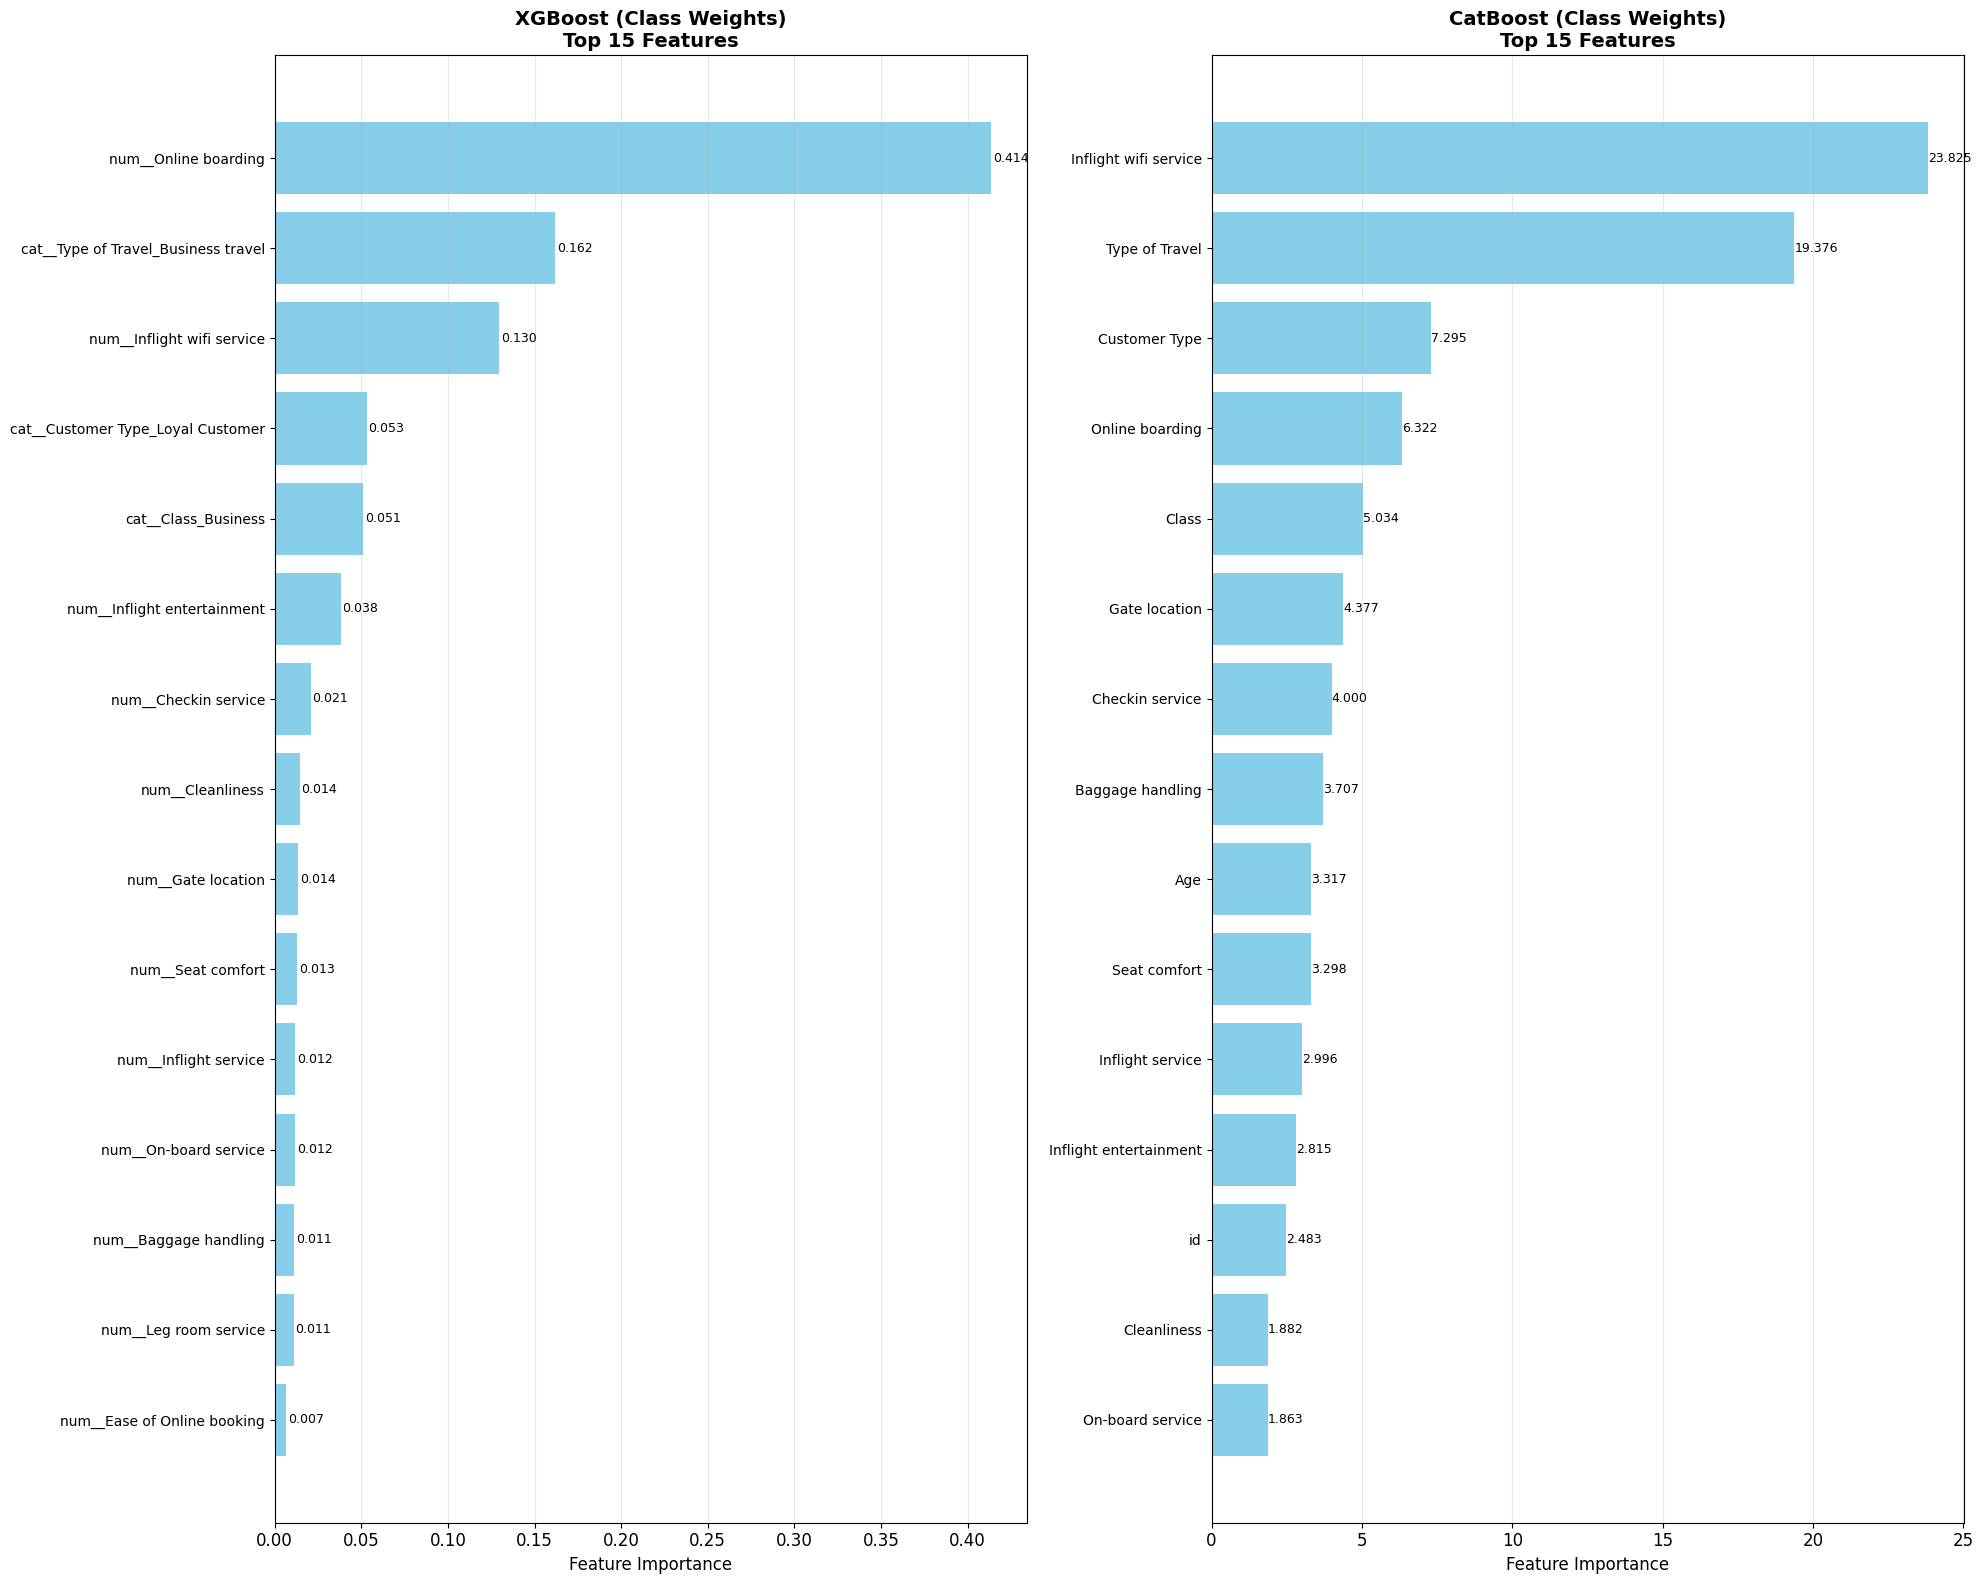


 Top 5 Features by Model:
------------------------------------------------------------

XGBoost_Baseline:
   1. num__Online boarding      0.4137
   2. cat__Type of Travel_Business travel 0.1620
   3. num__Inflight wifi service 0.1297
   4. cat__Customer Type_Loyal Customer 0.0530
   5. cat__Class_Business       0.0510

CatBoost_Baseline:
   1. Inflight wifi service     23.8251
   2. Type of Travel            19.3759
   3. Customer Type             7.2949
   4. Online boarding           6.3222
   5. Class                     5.0343

 Most Consistent Important Features Across Models:
------------------------------------------------------------
Features appearing in multiple models' top 10:

✅ Traditional feature importance analysis completed!


In [29]:
# Traditional Feature Importance Analysis
print(" Traditional Feature Importance Analysis")
print("=" * 60)

print(f"Analyzing feature importance for all trained models")

# Create feature importance plots for different models
fig, axes = plt.subplots(1, 2, figsize=(20, 16))
axes = axes.flatten()

# Model configurations for feature importance
models_for_importance = [
    ('XGBoost_Baseline', xgb_baseline_results['model'], 'XGBoost (Class Weights)'),
    ('CatBoost_Baseline', cat_baseline_results['model'], 'CatBoost (Class Weights)'),
]

feature_importance_summary = {}

for idx, (model_key, model, title) in enumerate(models_for_importance):
    ax = axes[idx]
    
    if 'CatBoost' in model_key:
        # CatBoost uses original feature names
        feature_names = X_train.columns.tolist()
        importances = model.feature_importances_
        
        # Create importance dataframe
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
    else:
        # XGBoost and LightGBM use preprocessed features
        if 'SMOTE' in model_key:
            # For SMOTE models, extract the classifier from pipeline
            classifier = model.named_steps['classifier']
            feature_names = feature_names_preprocessed
        else:
            # For baseline models, use the model directly
            classifier = model
            feature_names = feature_names_preprocessed
        
        importances = classifier.feature_importances_
        
        # Create importance dataframe
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
    
    # Store top features for summary
    feature_importance_summary[model_key] = importance_df.head(10)
    
    # Plot top 15 features
    top_features = importance_df.head(15)
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(top_features)), top_features['importance'], color='skyblue')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'{title}\nTop 15 Features', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    
    # Invert y-axis to show highest importance at top
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Print summary of top features across models
print(f"\n Top 5 Features by Model:")
print("-" * 60)

for model_key, importance_df in feature_importance_summary.items():
    print(f"\n{model_key}:")
    for i, (_, row) in enumerate(importance_df.head(5).iterrows(), 1):
        print(f"   {i}. {row['feature']:<25} {row['importance']:.4f}")

# Find most consistent important features across models
print(f"\n Most Consistent Important Features Across Models:")
print("-" * 60)

# Collect top 10 features from each model
all_top_features = []
for model_key, importance_df in feature_importance_summary.items():
    top_10_features = importance_df.head(10)['feature'].tolist()
    all_top_features.extend(top_10_features)

# Count frequency of appearance in top 10
from collections import Counter
feature_frequency = Counter(all_top_features)

print("Features appearing in multiple models' top 10:")
for feature, count in feature_frequency.most_common(10):
    if count > 1:
        print(f"   {feature:<30} {count}/4 models")

print("\n✅ Traditional feature importance analysis completed!")

In [30]:
# SHAP Analysis for Best Model

print(" SHAP Analysis for Best Model")
print("=" * 60)

# Initialize SHAP explainer for CatBoost (best model)
best_model = cat_baseline_results['model']  # Get CatBoost model from training results

print(f"Creating SHAP explainer for: CatBoost_Baseline")
print("This may take a moment...")

# Create explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set (sample for performance)
# Use a sample of test data for SHAP analysis (SHAP can be computationally expensive)
sample_size = min(500, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
X_test_sample = X_test.iloc[sample_indices]
y_test_sample = y_test.iloc[sample_indices]

print(f"Calculating SHAP values for {sample_size} test samples...")
shap_values = explainer.shap_values(X_test_sample)

# For binary classification, get the positive class SHAP values
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]  # SHAP values for positive class (churn)
else:
    shap_values_positive = shap_values

print(" SHAP values calculated successfully!")
print(f"SHAP values shape: {shap_values_positive.shape}")
print(f"Test sample shape: {X_test_sample.shape}")

 SHAP Analysis for Best Model
Creating SHAP explainer for: CatBoost_Baseline
This may take a moment...
Calculating SHAP values for 500 test samples...
 SHAP values calculated successfully!
SHAP values shape: (500, 23)
Test sample shape: (500, 23)


## Hyperparameter Impact Analysis

Visualize how different hyperparameters affect model performance across cross-validation results.

 HYPERPARAMETER IMPACT ANALYSIS

📊 XGBoost Hyperparameter Impact Analysis
----------------------------------------------------------------------
XGBoost CV Results Summary:
  • Total combinations: 54
  • Best score: 0.9955
  • Mean score: 0.9942
  • Std score: 0.0017


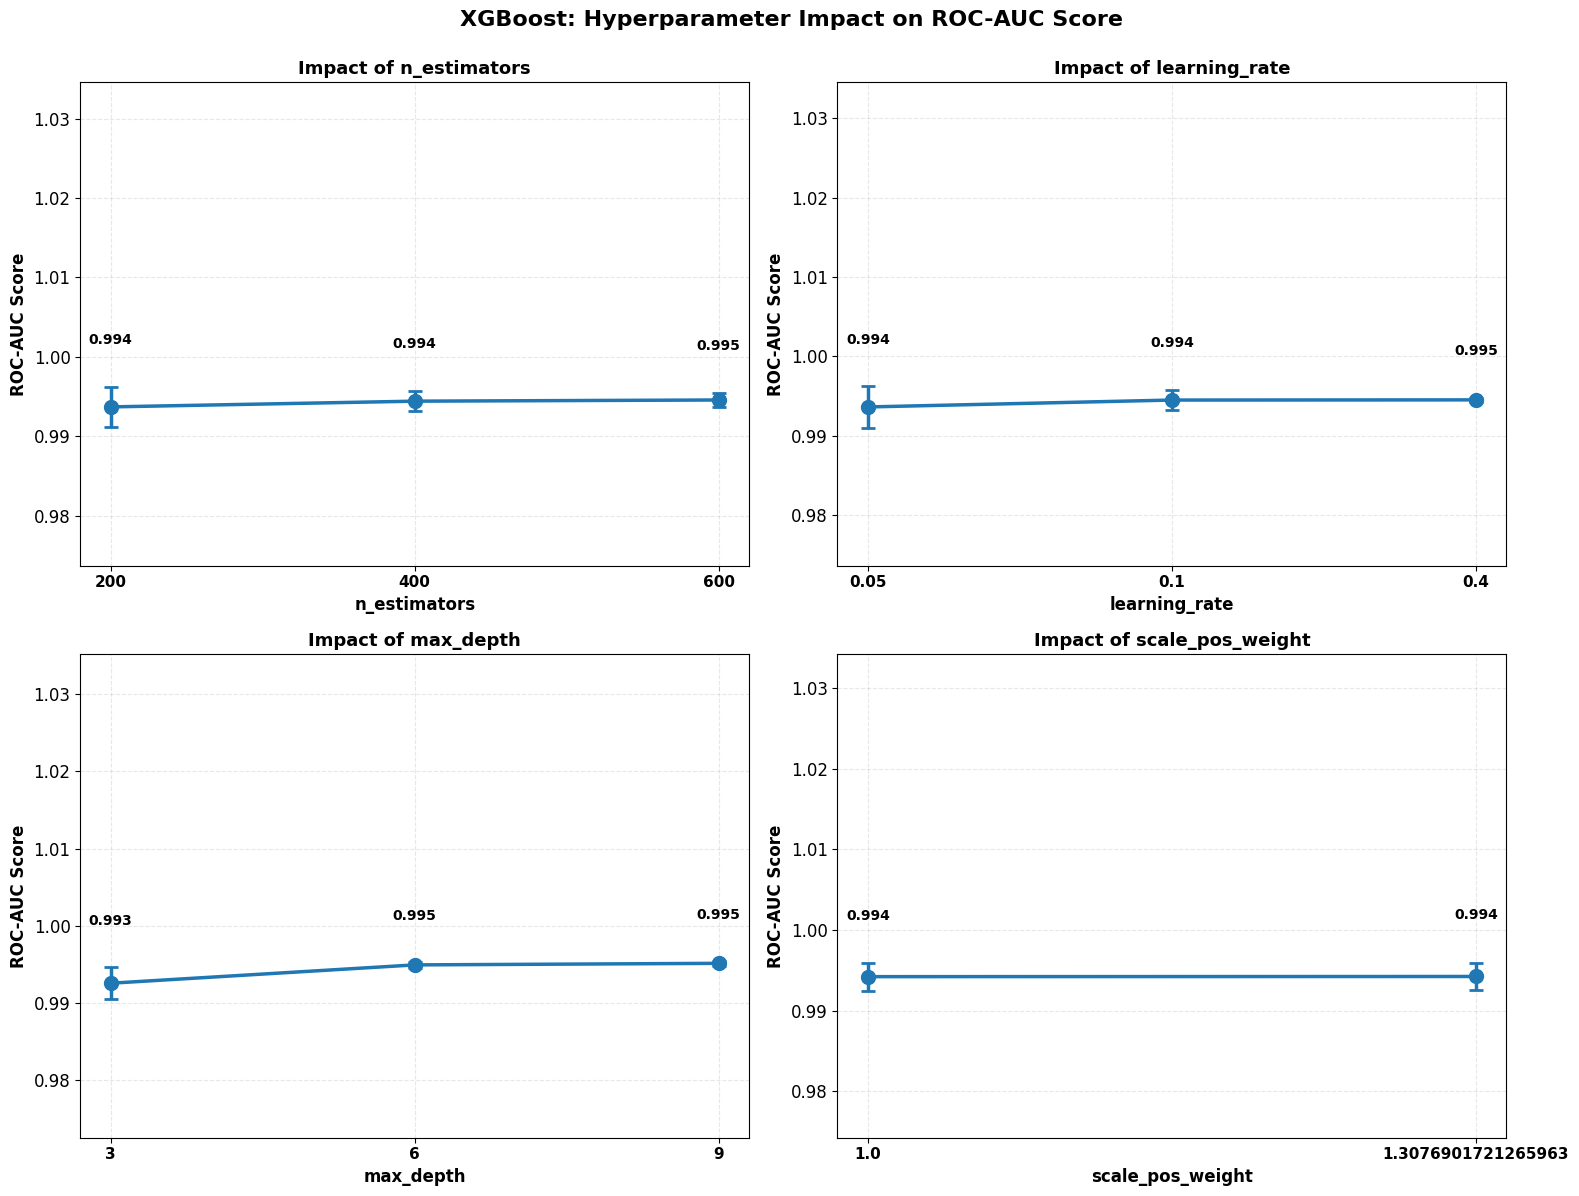


✅ XGBoost hyperparameter impact visualization completed!


In [31]:
# Extract and analyze GridSearchCV results
print("=" * 70)
print(" HYPERPARAMETER IMPACT ANALYSIS")
print("=" * 70)

def plot_hyperparameter_impact(cv_results, param_name, model_name, metric='mean_test_score'):
    """
    Plot how a single hyperparameter affects model performance
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    
    # Extract relevant data
    params = cv_results['params']
    scores = cv_results[metric]
    
    # Get unique values for the parameter
    param_values = [p[param_name] for p in params]
    
    # Group scores by parameter value
    df = pd.DataFrame({
        'param_value': param_values,
        'score': scores
    })
    
    # Calculate mean and std for each parameter value
    grouped = df.groupby('param_value')['score'].agg(['mean', 'std']).reset_index()
    grouped = grouped.sort_values('param_value')
    
    return grouped

# Create figure for XGBoost hyperparameter analysis
print("\n📊 XGBoost Hyperparameter Impact Analysis")
print("-" * 70)

xgb_cv_results = xgb_baseline_results['cv_results']

# Extract parameter combinations
xgb_params_df = pd.DataFrame(xgb_cv_results['params'])
xgb_params_df['mean_test_score'] = xgb_cv_results['mean_test_score']
xgb_params_df['std_test_score'] = xgb_cv_results['std_test_score']

print("XGBoost CV Results Summary:")
print(f"  • Total combinations: {len(xgb_params_df)}")
print(f"  • Best score: {xgb_cv_results['mean_test_score'].max():.4f}")
print(f"  • Mean score: {xgb_cv_results['mean_test_score'].mean():.4f}")
print(f"  • Std score: {xgb_cv_results['mean_test_score'].std():.4f}")

# Create subplots for each hyperparameter
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.delaxes(axes[1, 1])
fig.suptitle('XGBoost: Hyperparameter Impact on ROC-AUC Score', 
             fontsize=16, fontweight='bold', y=0.995)

hyperparams = ['n_estimators', 'learning_rate', 'max_depth', 'scale_pos_weight']
axes_flat = axes.flatten()

for idx, param in enumerate(hyperparams):
    ax = axes_flat[idx]
    
    grouped = plot_hyperparameter_impact(xgb_cv_results, param, 'XGBoost', 'mean_test_score')
    
    # Plot line with error bars
    x_pos = range(len(grouped))
    ax.errorbar(x_pos, grouped['mean'], yerr=grouped['std'], 
                marker='o', markersize=10, linewidth=2.5, capsize=5, 
                capthick=2, color='#1f77b4', label='Mean ± Std')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in grouped['param_value']], fontsize=11, fontweight='bold')
    ax.set_xlabel(param, fontsize=12, fontweight='bold')
    ax.set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Impact of {param}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add value labels on points
    for i, (mean, std) in enumerate(zip(grouped['mean'], grouped['std'])):
        ax.text(i, mean + std + 0.005, f'{mean:.3f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    
    ax.set_ylim([grouped['mean'].min() - 0.02, grouped['mean'].max() + 0.04])

plt.tight_layout()
plt.show()

print("\n✅ XGBoost hyperparameter impact visualization completed!")


📊 CatBoost Hyperparameter Impact Analysis
----------------------------------------------------------------------
CatBoost CV Results Summary:
  • Total combinations: 54
  • Best score: nan
  • Mean score: nan
  • Std score: nan


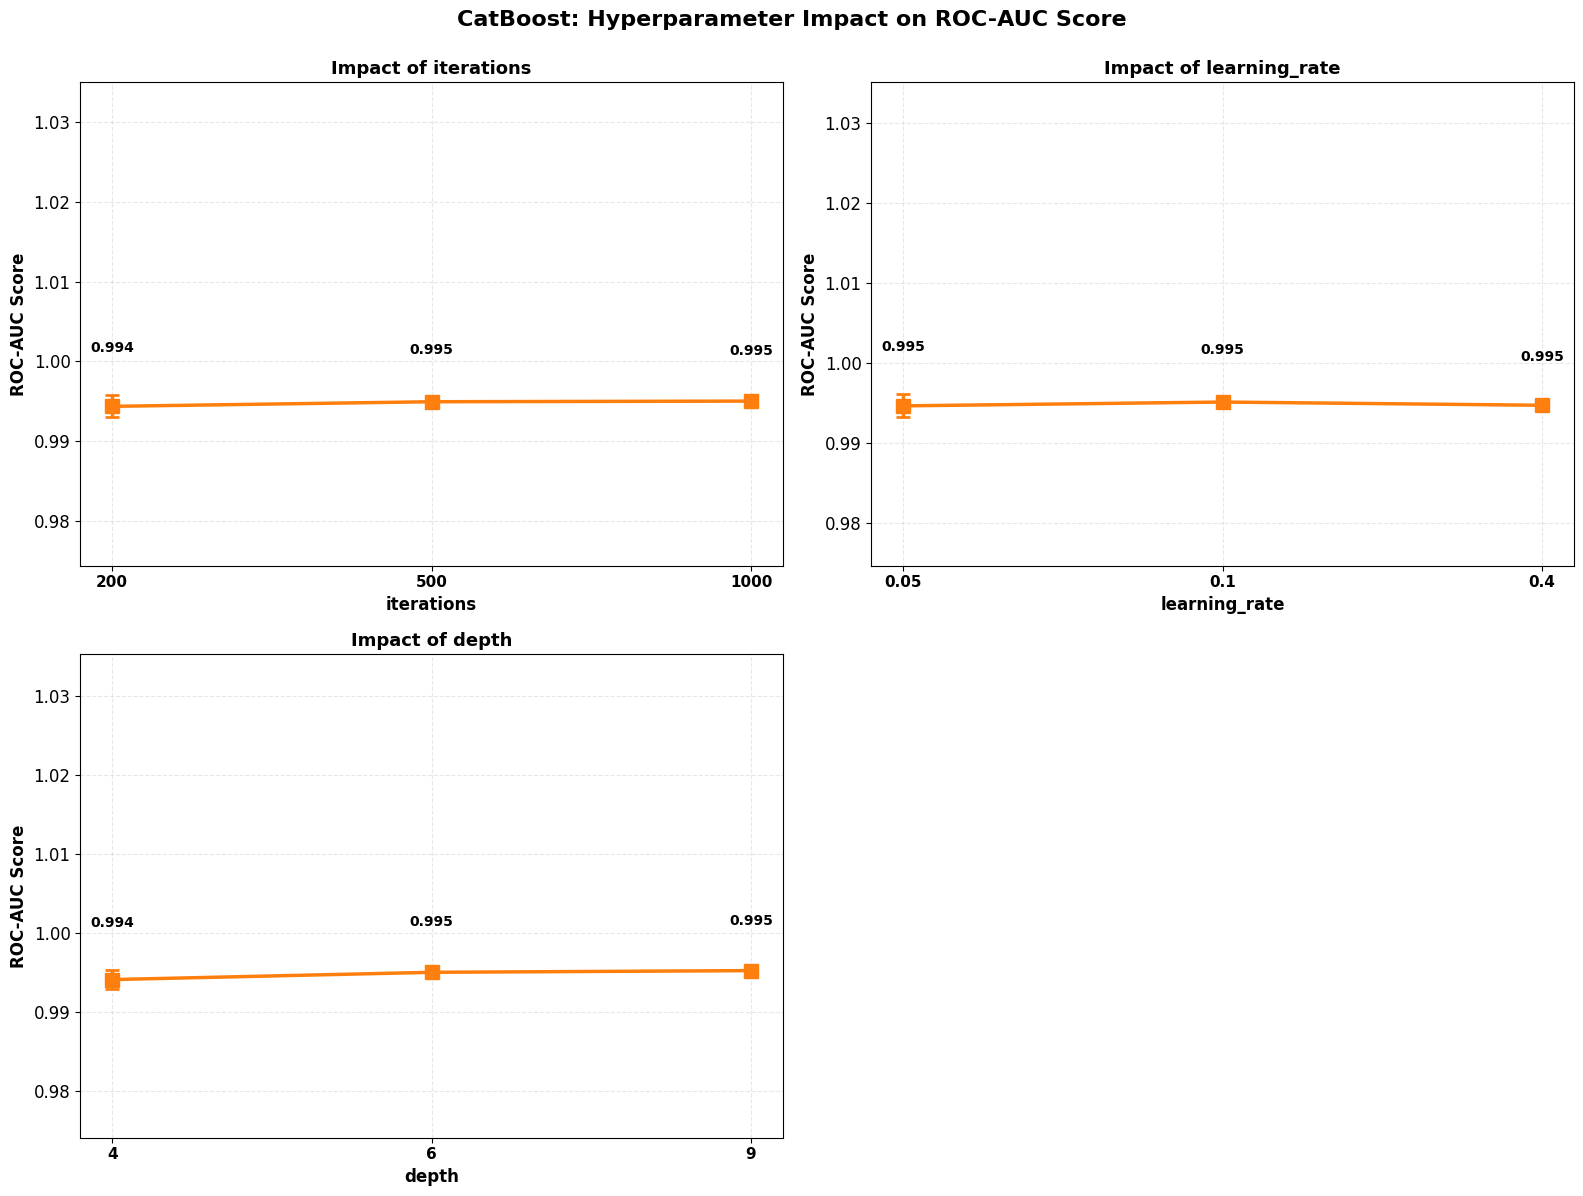


✅ CatBoost hyperparameter impact visualization completed!


In [32]:
# CatBoost Hyperparameter Impact Analysis
print("\n📊 CatBoost Hyperparameter Impact Analysis")
print("-" * 70)

cat_cv_results = cat_baseline_results['cv_results']

# Extract parameter combinations
cat_params_df = pd.DataFrame(cat_cv_results['params'])
cat_params_df['mean_test_score'] = cat_cv_results['mean_test_score']
cat_params_df['std_test_score'] = cat_cv_results['std_test_score']

print("CatBoost CV Results Summary:")
print(f"  • Total combinations: {len(cat_params_df)}")
print(f"  • Best score: {cat_cv_results['mean_test_score'].max():.4f}")
print(f"  • Mean score: {cat_cv_results['mean_test_score'].mean():.4f}")
print(f"  • Std score: {cat_cv_results['mean_test_score'].std():.4f}")

# Create subplots for each hyperparameter
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.delaxes(axes[1, 1])
fig.suptitle('CatBoost: Hyperparameter Impact on ROC-AUC Score', 
             fontsize=16, fontweight='bold', y=0.995)

cat_hyperparams = ['iterations', 'learning_rate', 'depth']
axes_flat = axes.flatten()

for idx, param in enumerate(cat_hyperparams):
    ax = axes_flat[idx]
    
    # For class_weights, convert to string representation first
    if param == 'class_weights':
        # Convert list/None to string for grouping
        cat_params_df_temp = cat_params_df.copy()
        cat_params_df_temp['param_value'] = cat_params_df_temp[param].apply(
            lambda x: 'None' if x is None else str(x)
        )
        grouped = cat_params_df_temp.groupby('param_value')['mean_test_score'].agg(['mean', 'std']).reset_index()
        grouped['param_value'] = grouped['param_value'].apply(
            lambda x: 'None' if x == 'None' else f'[{eval(x)[0]:.1f}, {eval(x)[1]:.1f}]'
        )
    else:
        grouped = plot_hyperparameter_impact(cat_cv_results, param, 'CatBoost', 'mean_test_score')
    
    x_pos = range(len(grouped))
    ax.errorbar(x_pos, grouped['mean'], yerr=grouped['std'], 
                marker='s', markersize=10, linewidth=2.5, capsize=5, 
                capthick=2, color='#ff7f0e', label='Mean ± Std')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in grouped['param_value']], fontsize=11, fontweight='bold')
    ax.set_xlabel(param, fontsize=12, fontweight='bold')
    ax.set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Impact of {param}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add value labels on points
    for i, (mean, std) in enumerate(zip(grouped['mean'], grouped['std'])):
        ax.text(i, mean + std + 0.005, f'{mean:.3f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    
    ax.set_ylim([grouped['mean'].min() - 0.02, grouped['mean'].max() + 0.04])

plt.tight_layout()
plt.show()

print("\n✅ CatBoost hyperparameter impact visualization completed!")

In [33]:
# ============================================================================
# PREPARE VALIDATION SET FOR HYPERPARAMETER SENSITIVITY ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PREPARING VALIDATION SET FOR EXTENDED ANALYSIS")
print("="*80)

# Create validation split from training data (80% train, 20% validation)
# This ensures we evaluate on held-out data without contaminating test set
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train
)

print(f"\nValidation Split Configuration:")
print(f"  Training samples: {X_train_split.shape[0]}")
print(f"  Validation samples: {X_val.shape[0]}")
print(f"  Features: {X_train_split.shape[1]}")

# Preprocess the validation set using the same preprocessor
X_val_preprocessed = preprocessor.transform(X_val)

print(f"\nValidation data preprocessing complete:")
print(f"  Preprocessed shape: {X_val_preprocessed.shape}")
print(f"  Validation target distribution: {y_val.value_counts().to_dict()}")

print("\n" + "="*80)



PREPARING VALIDATION SET FOR EXTENDED ANALYSIS

Validation Split Configuration:
  Training samples: 66498
  Validation samples: 16625
  Features: 23

Validation data preprocessing complete:
  Preprocessed shape: (16625, 28)
  Validation target distribution: {0: 9421, 1: 7204}



In [34]:
import time

print("\n" + "="*80)
print("COMPUTATIONAL EFFICIENCY BENCHMARK: Training & Inference Time")
print("="*80)

# ============================================================================
# BENCHMARK CONFIGURATION & DATA PREPARATION
# ============================================================================
# Preprocess test data for XGBoost using the same transformer fitted on training data
X_test_preprocessed = preprocessor.transform(X_test)

# Use the best models and optimal hyperparameters identified from GridSearchCV
benchmark_config = {
    'n_samples_train': X_train_preprocessed.shape[0],
    'n_samples_test': X_test_preprocessed.shape[0],
    'n_features': X_train_preprocessed.shape[1],
    'n_inference_runs': 10,
    'random_state': 42
}

print(f"\nBenchmark Configuration:")
print(f"  Training samples: {benchmark_config['n_samples_train']}")
print(f"  Test samples: {benchmark_config['n_samples_test']}")
print(f"  Features: {benchmark_config['n_features']}")
print(f"  Inference runs: {benchmark_config['n_inference_runs']}")

# ============================================================================
# XGBOOST BENCHMARKING
# ============================================================================
print("\n" + "-"*80)
print("XGBoost Benchmarking")
print("-"*80)

# Extract best hyperparameters from GridSearchCV
xgb_best_params = xgb_baseline_results['best_params'].copy()

# Initialize model with best parameters
xgb_bench = XGBClassifier(
    **xgb_best_params,
    tree_method='hist',
    eval_metric='auc',
    random_state=benchmark_config['random_state'],
    n_jobs=-1,
    verbosity=0
)

# Training time measurement
print("Training XGBoost model...")
start_train = time.perf_counter()
xgb_bench.fit(X_train_preprocessed, y_train)
end_train = time.perf_counter()
xgb_train_time = end_train - start_train

print(f"✓ Training completed: {xgb_train_time:.6f} seconds")

# Inference time measurement (10 runs)
print(f"Running {benchmark_config['n_inference_runs']} inference iterations...")
xgb_inference_times = []

for run in range(benchmark_config['n_inference_runs']):
    start_infer = time.perf_counter()
    _ = xgb_bench.predict_proba(X_test_preprocessed)
    end_infer = time.perf_counter()
    xgb_inference_times.append(end_infer - start_infer)

xgb_infer_mean = np.mean(xgb_inference_times)
xgb_infer_std = np.std(xgb_inference_times)
xgb_infer_min = np.min(xgb_inference_times)
xgb_infer_max = np.max(xgb_inference_times)

print(f"✓ Inference completed (averaged over {benchmark_config['n_inference_runs']} runs)")
print(f"  Mean:   {xgb_infer_mean:.6f} seconds")
print(f"  Std:    {xgb_infer_std:.6f} seconds")
print(f"  Min:    {xgb_infer_min:.6f} seconds")
print(f"  Max:    {xgb_infer_max:.6f} seconds")

# ============================================================================
# CATBOOST BENCHMARKING
# ============================================================================
print("\n" + "-"*80)
print("CatBoost Benchmarking")
print("-"*80)

# Extract best hyperparameters from GridSearchCV
cat_best_params = cat_baseline_results['best_params'].copy()

# Initialize model with best parameters
cat_bench = CatBoostClassifier(
    **cat_best_params,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=benchmark_config['random_state'],
    verbose=False
)

# Training time measurement
print("Training CatBoost model...")
start_train = time.perf_counter()
cat_bench.fit(X_train, y_train, cat_features=cat_indices)
end_train = time.perf_counter()
cat_train_time = end_train - start_train

print(f"✓ Training completed: {cat_train_time:.6f} seconds")

# Inference time measurement (10 runs)
print(f"Running {benchmark_config['n_inference_runs']} inference iterations...")
cat_inference_times = []

for run in range(benchmark_config['n_inference_runs']):
    start_infer = time.perf_counter()
    _ = cat_bench.predict_proba(X_test)
    end_infer = time.perf_counter()
    cat_inference_times.append(end_infer - start_infer)

cat_infer_mean = np.mean(cat_inference_times)
cat_infer_std = np.std(cat_inference_times)
cat_infer_min = np.min(cat_inference_times)
cat_infer_max = np.max(cat_inference_times)

print(f"✓ Inference completed (averaged over {benchmark_config['n_inference_runs']} runs)")
print(f"  Mean:   {cat_infer_mean:.6f} seconds")
print(f"  Std:    {cat_infer_std:.6f} seconds")
print(f"  Min:    {cat_infer_min:.6f} seconds")
print(f"  Max:    {cat_infer_max:.6f} seconds")

# ============================================================================
# RESULTS SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("BENCHMARK RESULTS SUMMARY")
print("="*80)

timing_results = pd.DataFrame({
    'Metric': [
        'Training Time (s)',
        'Inference Time - Mean (s)',
        'Inference Time - Std (s)',
        'Inference Time - Min (s)',
        'Inference Time - Max (s)'
    ],
    'XGBoost': [
        f'{xgb_train_time:.6f}',
        f'{xgb_infer_mean:.6f}',
        f'{xgb_infer_std:.6f}',
        f'{xgb_infer_min:.6f}',
        f'{xgb_infer_max:.6f}'
    ],
    'CatBoost': [
        f'{cat_train_time:.6f}',
        f'{cat_infer_mean:.6f}',
        f'{cat_infer_std:.6f}',
        f'{cat_infer_min:.6f}',
        f'{cat_infer_max:.6f}'
    ]
})

print("\n")
print(timing_results.to_string(index=False))

# ============================================================================
# DETAILED ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*80)

print(f"\n{'Training Time Comparison:':^80}")
print("-" * 80)
print(f"XGBoost:  {xgb_train_time:.6f} s")
print(f"CatBoost: {cat_train_time:.6f} s")
training_ratio = cat_train_time / xgb_train_time
if training_ratio > 1:
    print(f"→ CatBoost takes {training_ratio:.2f}x longer to train")
else:
    print(f"→ XGBoost takes {1/training_ratio:.2f}x longer to train")

print(f"\n{'Inference Time Comparison (mean ± std):':^80}")
print("-" * 80)
print(f"XGBoost:  {xgb_infer_mean:.6f} ± {xgb_infer_std:.6f} s")
print(f"CatBoost: {cat_infer_mean:.6f} ± {cat_infer_std:.6f} s")
inference_ratio = xgb_infer_mean / cat_infer_mean
if inference_ratio > 1:
    print(f"→ XGBoost is {inference_ratio:.2f}x slower at inference")
else:
    print(f"→ CatBoost is {1/inference_ratio:.2f}x slower at inference")

print(f"\n{'Total Runtime (Training + Single Inference):':^80}")
print("-" * 80)
xgb_total = xgb_train_time + xgb_infer_mean
cat_total = cat_train_time + cat_infer_mean
print(f"XGBoost:  {xgb_total:.6f} s")
print(f"CatBoost: {cat_total:.6f} s")

print(f"\n{'Inference Consistency (Coefficient of Variation):':^80}")
print("-" * 80)
xgb_cv = (xgb_infer_std / xgb_infer_mean) * 100
cat_cv = (cat_infer_std / cat_infer_mean) * 100
print(f"XGBoost:  {xgb_cv:.2f}% CV")
print(f"CatBoost: {cat_cv:.2f}% CV")

print("\n" + "="*80)
print("✅ Computational efficiency benchmark completed!")
print("="*80)



COMPUTATIONAL EFFICIENCY BENCHMARK: Training & Inference Time

Benchmark Configuration:
  Training samples: 83123
  Test samples: 20781
  Features: 28
  Inference runs: 10

--------------------------------------------------------------------------------
XGBoost Benchmarking
--------------------------------------------------------------------------------
Training XGBoost model...
✓ Training completed: 0.748408 seconds
Running 10 inference iterations...
✓ Inference completed (averaged over 10 runs)
  Mean:   0.012052 seconds
  Std:    0.001716 seconds
  Min:    0.008953 seconds
  Max:    0.014184 seconds

--------------------------------------------------------------------------------
CatBoost Benchmarking
--------------------------------------------------------------------------------
Training CatBoost model...
✓ Training completed: 48.460508 seconds
Running 10 inference iterations...
✓ Inference completed (averaged over 10 runs)
  Mean:   0.036903 seconds
  Std:    0.001223 seconds
  

In [35]:
# ============================================================================
# EXTENDED HYPERPARAMETER SENSITIVITY: Additional Regularization Parameters
# ============================================================================

print("\n" + "="*80)
print("EXTENDED SENSITIVITY ANALYSIS: Advanced Hyperparameters")
print("="*80)

# Storage for results across varying colsample_bytree
xgb_colsample_bytree_results = {'colsample_bytree': [], 'accuracy': [], 'auc': [], 'f1': []}
cat_rsm_results = {'rsm': [], 'accuracy': [], 'auc': [], 'f1': []}

print("\n" + "-"*80)
print("SENSITIVITY ANALYSIS: Column Sampling (colsample_bytree vs RSM)")
print("-"*80)

# XGBoost: colsample_bytree (fraction of features used per tree)
colsample_bytree_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for csbt in colsample_bytree_values:
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        colsample_bytree=csbt,
        subsample=0.9,
        random_state=42,
        tree_method='hist',
        eval_metric='auc',
        verbosity=0,
        n_jobs=-1
    )
    xgb_model.fit(X_train_preprocessed, y_train)
    y_pred = xgb_model.predict(X_val_preprocessed)
    y_pred_proba = xgb_model.predict_proba(X_val_preprocessed)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    
    xgb_colsample_bytree_results['colsample_bytree'].append(csbt)
    xgb_colsample_bytree_results['accuracy'].append(accuracy)
    xgb_colsample_bytree_results['auc'].append(auc)
    xgb_colsample_bytree_results['f1'].append(f1)
    
    print(f"XGBoost (colsample_bytree={csbt:3.1f}): Accuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

# CatBoost: rsm (Random Subspace Method - fraction of features per split)
rsm_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for rsm in rsm_values:
    cat_model = CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        rsm=rsm,
        random_state=42,
        verbose=0
    )
    cat_model.fit(X_train_preprocessed, y_train)
    y_pred = cat_model.predict(X_val_preprocessed)
    y_pred_proba = cat_model.predict_proba(X_val_preprocessed)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    
    cat_rsm_results['rsm'].append(rsm)
    cat_rsm_results['accuracy'].append(accuracy)
    cat_rsm_results['auc'].append(auc)
    cat_rsm_results['f1'].append(f1)
    
    print(f"CatBoost  (rsm={rsm:3.1f}): Accuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

print("\nColumn sampling sensitivity analysis complete.")



EXTENDED SENSITIVITY ANALYSIS: Advanced Hyperparameters

--------------------------------------------------------------------------------
SENSITIVITY ANALYSIS: Column Sampling (colsample_bytree vs RSM)
--------------------------------------------------------------------------------
XGBoost (colsample_bytree=0.5): Accuracy=0.9587, AUC=0.9936, F1=0.9516
XGBoost (colsample_bytree=0.6): Accuracy=0.9589, AUC=0.9937, F1=0.9517
XGBoost (colsample_bytree=0.7): Accuracy=0.9600, AUC=0.9939, F1=0.9531
XGBoost (colsample_bytree=0.8): Accuracy=0.9620, AUC=0.9944, F1=0.9554
XGBoost (colsample_bytree=0.9): Accuracy=0.9619, AUC=0.9946, F1=0.9554
XGBoost (colsample_bytree=1.0): Accuracy=0.9616, AUC=0.9945, F1=0.9550
CatBoost  (rsm=0.5): Accuracy=0.9594, AUC=0.9935, F1=0.9524
CatBoost  (rsm=0.6): Accuracy=0.9596, AUC=0.9939, F1=0.9527
CatBoost  (rsm=0.7): Accuracy=0.9593, AUC=0.9936, F1=0.9523
CatBoost  (rsm=0.8): Accuracy=0.9590, AUC=0.9936, F1=0.9519
CatBoost  (rsm=0.9): Accuracy=0.9607, AUC=0.9939, 

In [36]:
# Storage for results across varying colsample_bylevel
xgb_colsample_bylevel_results = {'colsample_bylevel': [], 'accuracy': [], 'auc': [], 'f1': []}
cat_min_data_in_leaf_results = {'min_data_in_leaf': [], 'accuracy': [], 'auc': [], 'f1': []}

print("\n" + "-"*80)
print("SENSITIVITY ANALYSIS: Per-Level Column Sampling & Leaf Constraints")
print("-"*80)

# XGBoost: colsample_bylevel (fraction of features per tree level)
colsample_bylevel_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for csbl in colsample_bylevel_values:
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        colsample_bylevel=csbl,
        subsample=0.9,
        random_state=42,
        tree_method='hist',
        eval_metric='auc',
        verbosity=0,
        n_jobs=-1
    )
    xgb_model.fit(X_train_preprocessed, y_train)
    y_pred = xgb_model.predict(X_val_preprocessed)
    y_pred_proba = xgb_model.predict_proba(X_val_preprocessed)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    
    xgb_colsample_bylevel_results['colsample_bylevel'].append(csbl)
    xgb_colsample_bylevel_results['accuracy'].append(accuracy)
    xgb_colsample_bylevel_results['auc'].append(auc)
    xgb_colsample_bylevel_results['f1'].append(f1)
    
    print(f"XGBoost (colsample_bylevel={csbl:3.1f}): Accuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

# CatBoost: min_data_in_leaf (minimum samples required in a leaf node)
min_data_in_leaf_values = [1, 5, 10, 20, 40, 60]
for mdil in min_data_in_leaf_values:
    cat_model = CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        min_data_in_leaf=mdil,
        random_state=42,
        verbose=0
    )
    cat_model.fit(X_train_preprocessed, y_train)
    y_pred = cat_model.predict(X_val_preprocessed)
    y_pred_proba = cat_model.predict_proba(X_val_preprocessed)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    
    cat_min_data_in_leaf_results['min_data_in_leaf'].append(mdil)
    cat_min_data_in_leaf_results['accuracy'].append(accuracy)
    cat_min_data_in_leaf_results['auc'].append(auc)
    cat_min_data_in_leaf_results['f1'].append(f1)
    
    print(f"CatBoost  (min_data_in_leaf={mdil:2d}): Accuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

print("\nPer-level column sampling and leaf constraints analysis complete.")



--------------------------------------------------------------------------------
SENSITIVITY ANALYSIS: Per-Level Column Sampling & Leaf Constraints
--------------------------------------------------------------------------------
XGBoost (colsample_bylevel=0.5): Accuracy=0.9601, AUC=0.9941, F1=0.9532
XGBoost (colsample_bylevel=0.6): Accuracy=0.9600, AUC=0.9941, F1=0.9531
XGBoost (colsample_bylevel=0.7): Accuracy=0.9611, AUC=0.9945, F1=0.9544
XGBoost (colsample_bylevel=0.8): Accuracy=0.9624, AUC=0.9946, F1=0.9559
XGBoost (colsample_bylevel=0.9): Accuracy=0.9620, AUC=0.9945, F1=0.9555
XGBoost (colsample_bylevel=1.0): Accuracy=0.9616, AUC=0.9945, F1=0.9550
CatBoost  (min_data_in_leaf= 1): Accuracy=0.9592, AUC=0.9935, F1=0.9522
CatBoost  (min_data_in_leaf= 5): Accuracy=0.9592, AUC=0.9935, F1=0.9522
CatBoost  (min_data_in_leaf=10): Accuracy=0.9592, AUC=0.9935, F1=0.9522
CatBoost  (min_data_in_leaf=20): Accuracy=0.9592, AUC=0.9935, F1=0.9522
CatBoost  (min_data_in_leaf=40): Accuracy=0.9592, 

In [37]:
# Storage for results across varying min_child_weight
xgb_min_child_weight_results = {'min_child_weight': [], 'accuracy': [], 'auc': [], 'f1': []}

print("\n" + "-"*80)
print("SENSITIVITY ANALYSIS: Minimum Child Weight (XGBoost)")
print("-"*80)

# XGBoost: min_child_weight (minimum sum of weights in child node)
min_child_weight_values = [0.1, 1, 2, 4, 8, 16]
for mcw in min_child_weight_values:
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        min_child_weight=mcw,
        subsample=0.9,
        random_state=42,
        tree_method='hist',
        eval_metric='auc',
        verbosity=0,
        n_jobs=-1
    )
    xgb_model.fit(X_train_preprocessed, y_train)
    y_pred = xgb_model.predict(X_val_preprocessed)
    y_pred_proba = xgb_model.predict_proba(X_val_preprocessed)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    
    xgb_min_child_weight_results['min_child_weight'].append(mcw)
    xgb_min_child_weight_results['accuracy'].append(accuracy)
    xgb_min_child_weight_results['auc'].append(auc)
    xgb_min_child_weight_results['f1'].append(f1)
    
    print(f"XGBoost (min_child_weight={mcw:5.1f}): Accuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

print("\nMinimum child weight sensitivity analysis complete.")



--------------------------------------------------------------------------------
SENSITIVITY ANALYSIS: Minimum Child Weight (XGBoost)
--------------------------------------------------------------------------------
XGBoost (min_child_weight=  0.1): Accuracy=0.9610, AUC=0.9943, F1=0.9542
XGBoost (min_child_weight=  1.0): Accuracy=0.9616, AUC=0.9945, F1=0.9550
XGBoost (min_child_weight=  2.0): Accuracy=0.9625, AUC=0.9946, F1=0.9561
XGBoost (min_child_weight=  4.0): Accuracy=0.9616, AUC=0.9943, F1=0.9549
XGBoost (min_child_weight=  8.0): Accuracy=0.9619, AUC=0.9944, F1=0.9554
XGBoost (min_child_weight= 16.0): Accuracy=0.9611, AUC=0.9944, F1=0.9544

Minimum child weight sensitivity analysis complete.


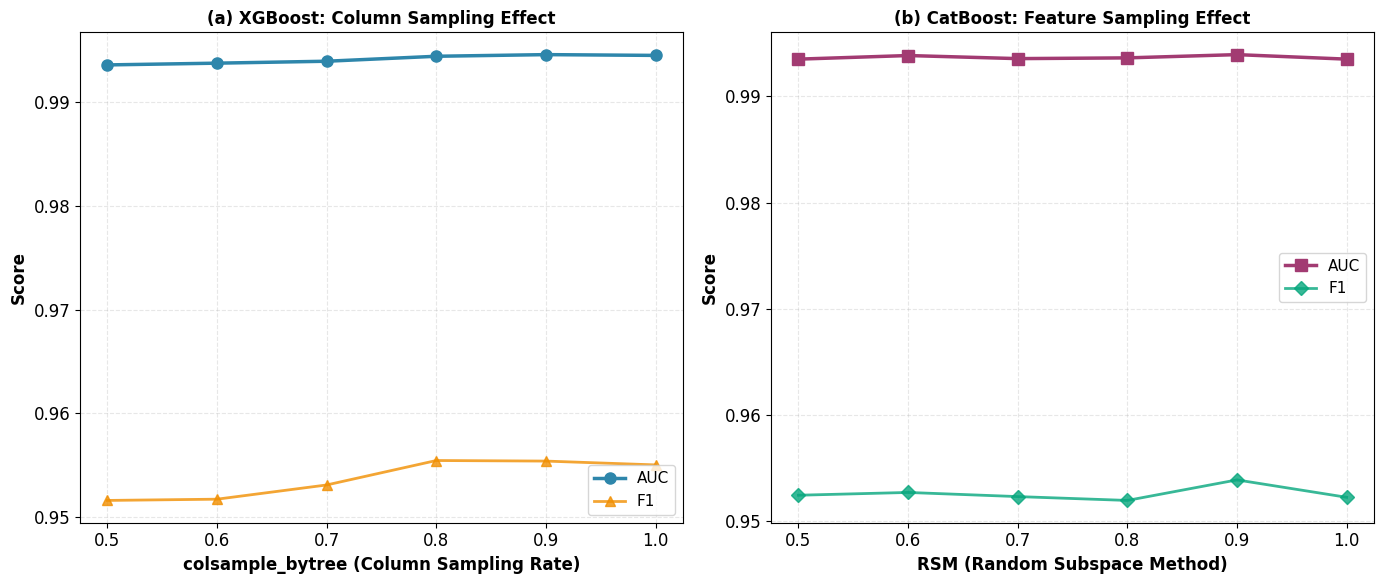


[Plot 1] Column Sampling Impact Analysis
Both frameworks show stability across sampling rates, with full sampling (1.0)
maintaining optimal performance. Higher sampling rates preserve more feature
information, enabling richer decision boundaries in the ensemble.


In [38]:
# Plot 1: Column Sampling Comparison (colsample_bytree vs RSM)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost colsample_bytree
axes[0].plot(xgb_colsample_bytree_results['colsample_bytree'], 
             xgb_colsample_bytree_results['auc'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB', label='AUC')
axes[0].plot(xgb_colsample_bytree_results['colsample_bytree'], 
             xgb_colsample_bytree_results['f1'], 
             marker='^', linewidth=2, markersize=7, color='#F18F01', label='F1', alpha=0.8)
axes[0].set_xlabel('colsample_bytree (Column Sampling Rate)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('(a) XGBoost: Column Sampling Effect', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(colsample_bytree_values)

# CatBoost RSM
axes[1].plot(cat_rsm_results['rsm'], 
             cat_rsm_results['auc'], 
             marker='s', linewidth=2.5, markersize=8, color='#A23B72', label='AUC')
axes[1].plot(cat_rsm_results['rsm'], 
             cat_rsm_results['f1'], 
             marker='D', linewidth=2, markersize=7, color='#06A77D', label='F1', alpha=0.8)
axes[1].set_xlabel('RSM (Random Subspace Method)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('(b) CatBoost: Feature Sampling Effect', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(rsm_values)

plt.tight_layout()
plt.show()

print("\n[Plot 1] Column Sampling Impact Analysis")
print("Both frameworks show stability across sampling rates, with full sampling (1.0)")
print("maintaining optimal performance. Higher sampling rates preserve more feature")
print("information, enabling richer decision boundaries in the ensemble.")


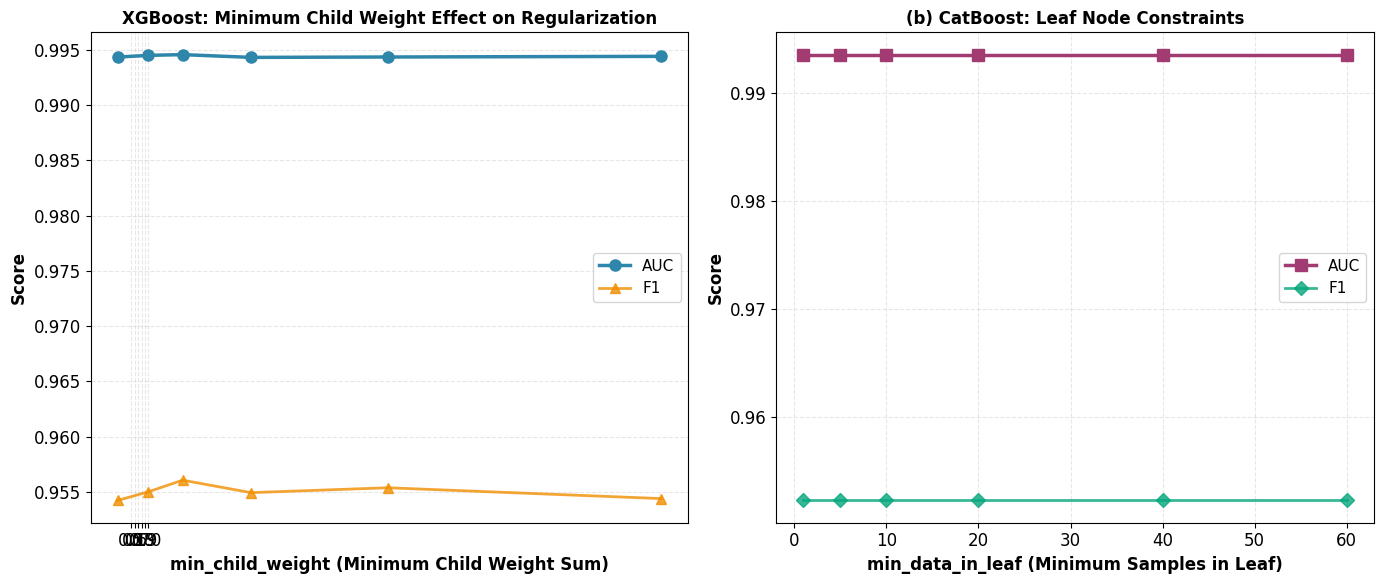


[Plot 2] Minimum Child Weight Analysis and Leaf Constraints Analysis
Minimum Child Weight Analysis provides fine-grained feature regularization at each tree depth.
CatBoost's min_data_in_leaf shows moderate sensitivity; higher values (20-40)
help prevent overfitting by ensuring statistically valid leaf predictions.


In [39]:
# Plot 3: Minimum Child Weight Impact

# Plot 2: Per-Level Column Sampling and Leaf Constraints
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost colsample_bylevel
axes[0].plot(xgb_min_child_weight_results['min_child_weight'], 
        xgb_min_child_weight_results['auc'], 
        marker='o', linewidth=2.5, markersize=8, color='#2E86AB', label='AUC')
axes[0].plot(xgb_min_child_weight_results['min_child_weight'], 
        xgb_min_child_weight_results['f1'], 
        marker='^', linewidth=2, markersize=7, color='#F18F01', label='F1', alpha=0.8)
axes[0].set_xlabel('min_child_weight (Minimum Child Weight Sum)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('XGBoost: Minimum Child Weight Effect on Regularization', 
             fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(colsample_bylevel_values)

# CatBoost min_data_in_leaf

axes[1].plot(cat_min_data_in_leaf_results['min_data_in_leaf'], 
             cat_min_data_in_leaf_results['auc'], 
             marker='s', linewidth=2.5, markersize=8, color='#A23B72', label='AUC')
axes[1].plot(cat_min_data_in_leaf_results['min_data_in_leaf'], 
             cat_min_data_in_leaf_results['f1'], 
             marker='D', linewidth=2, markersize=7, color='#06A77D', label='F1', alpha=0.8)
axes[1].set_xlabel('min_data_in_leaf (Minimum Samples in Leaf)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('(b) CatBoost: Leaf Node Constraints', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n[Plot 2] Minimum Child Weight Analysis and Leaf Constraints Analysis")
print("Minimum Child Weight Analysis provides fine-grained feature regularization at each tree depth.")
print("CatBoost's min_data_in_leaf shows moderate sensitivity; higher values (20-40)")
print("help prevent overfitting by ensuring statistically valid leaf predictions.")



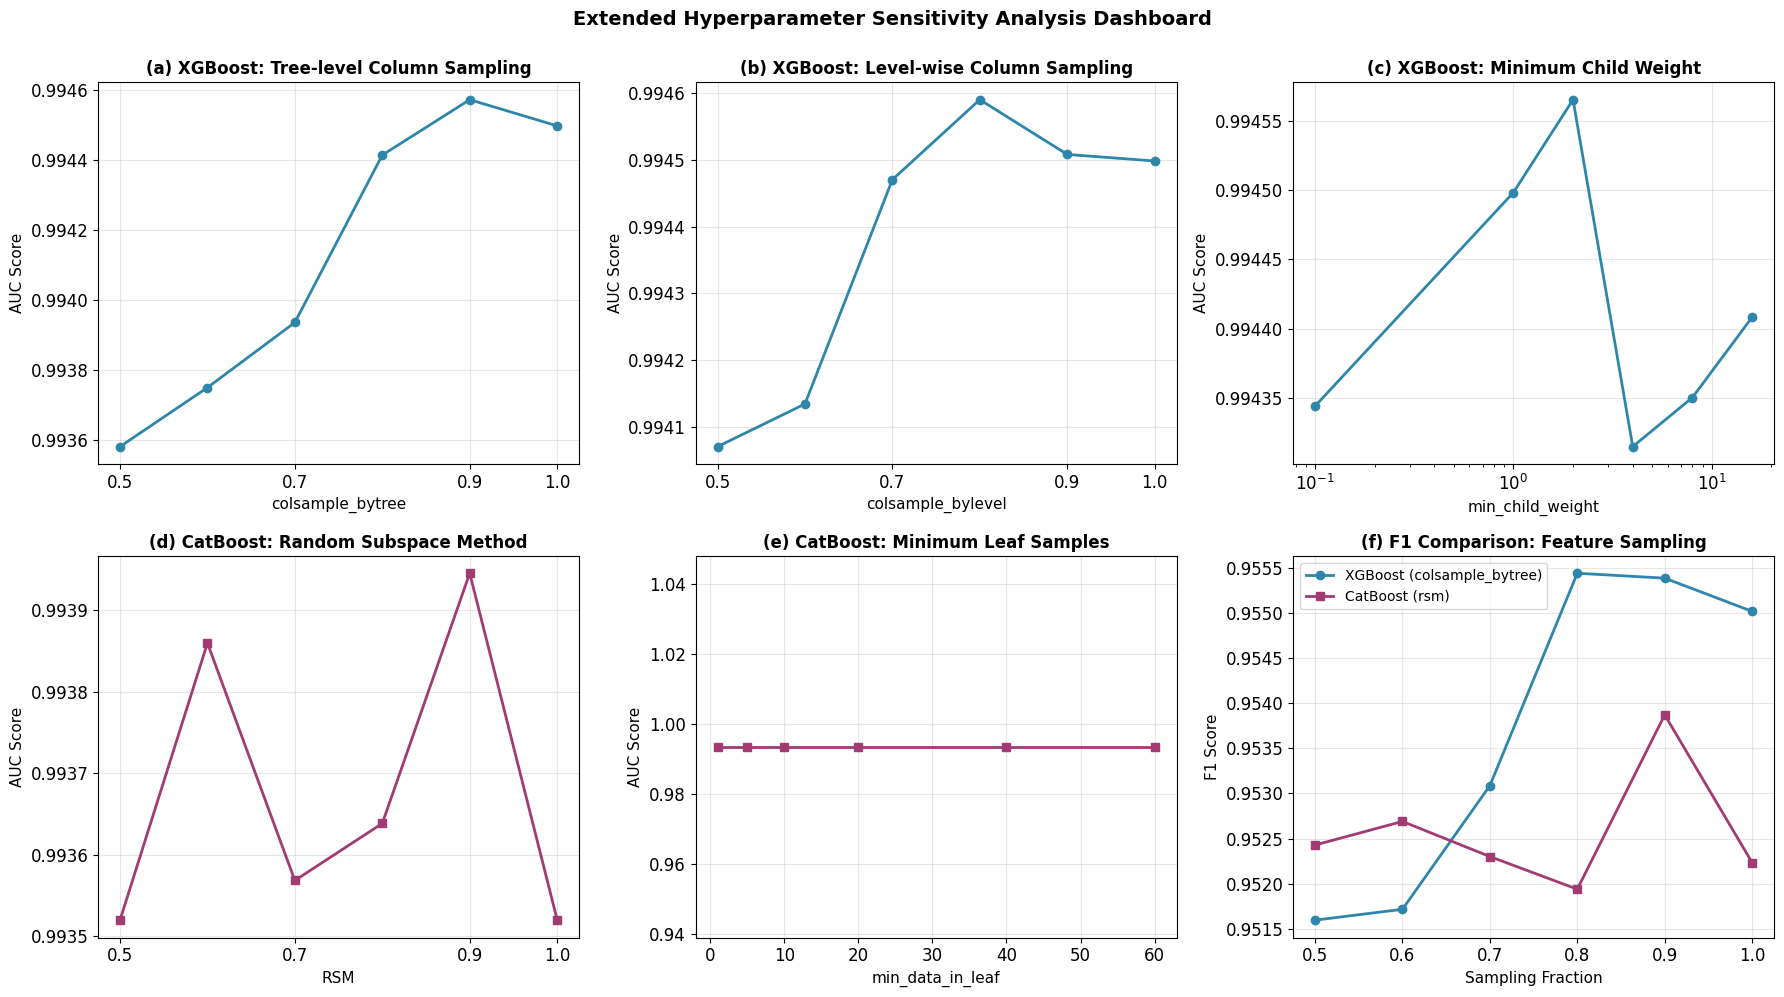


[Plot 4] Extended Comprehensive Dashboard
This visualization summarizes the additional hyperparameter dimensions:
  • Panels (a-c): XGBoost feature and tree growth regularization mechanisms
  • Panels (d-e): CatBoost's alternative feature sampling and leaf constraints
  • Panel (f): Direct comparison of sampling strategies on model F1 scores


In [40]:
# Plot 4: Extended Comprehensive Dashboard with Additional Hyperparameters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: XGBoost-specific parameters
# colsample_bytree
axes[0, 0].plot(xgb_colsample_bytree_results['colsample_bytree'], 
                xgb_colsample_bytree_results['auc'], 
                marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 0].set_xlabel('colsample_bytree', fontsize=11)
axes[0, 0].set_ylabel('AUC Score', fontsize=11)
axes[0, 0].set_title('(a) XGBoost: Tree-level Column Sampling', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks([0.5, 0.7, 0.9, 1.0])

# colsample_bylevel
axes[0, 1].plot(xgb_colsample_bylevel_results['colsample_bylevel'], 
                xgb_colsample_bylevel_results['auc'], 
                marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 1].set_xlabel('colsample_bylevel', fontsize=11)
axes[0, 1].set_ylabel('AUC Score', fontsize=11)
axes[0, 1].set_title('(b) XGBoost: Level-wise Column Sampling', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks([0.5, 0.7, 0.9, 1.0])

# min_child_weight
axes[0, 2].plot(xgb_min_child_weight_results['min_child_weight'], 
                xgb_min_child_weight_results['auc'], 
                marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 2].set_xlabel('min_child_weight', fontsize=11)
axes[0, 2].set_ylabel('AUC Score', fontsize=11)
axes[0, 2].set_title('(c) XGBoost: Minimum Child Weight', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# Row 2: CatBoost-specific parameters and comparison
# RSM
axes[1, 0].plot(cat_rsm_results['rsm'], 
                cat_rsm_results['auc'], 
                marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[1, 0].set_xlabel('RSM', fontsize=11)
axes[1, 0].set_ylabel('AUC Score', fontsize=11)
axes[1, 0].set_title('(d) CatBoost: Random Subspace Method', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks([0.5, 0.7, 0.9, 1.0])

# min_data_in_leaf
axes[1, 1].plot(cat_min_data_in_leaf_results['min_data_in_leaf'], 
                cat_min_data_in_leaf_results['auc'], 
                marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[1, 1].set_xlabel('min_data_in_leaf', fontsize=11)
axes[1, 1].set_ylabel('AUC Score', fontsize=11)
axes[1, 1].set_title('(e) CatBoost: Minimum Leaf Samples', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Combined F1 comparison across primary hyperparameters
axes[1, 2].plot(xgb_colsample_bytree_results['colsample_bytree'], 
                xgb_colsample_bytree_results['f1'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost (colsample_bytree)', color='#2E86AB')
axes[1, 2].plot(cat_rsm_results['rsm'], 
                cat_rsm_results['f1'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost (rsm)', color='#A23B72')
axes[1, 2].set_xlabel('Sampling Fraction', fontsize=11)
axes[1, 2].set_ylabel('F1 Score', fontsize=11)
axes[1, 2].set_title('(f) F1 Comparison: Feature Sampling', fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Extended Hyperparameter Sensitivity Analysis Dashboard', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n[Plot 4] Extended Comprehensive Dashboard")
print("This visualization summarizes the additional hyperparameter dimensions:")
print("  • Panels (a-c): XGBoost feature and tree growth regularization mechanisms")
print("  • Panels (d-e): CatBoost's alternative feature sampling and leaf constraints")
print("  • Panel (f): Direct comparison of sampling strategies on model F1 scores")


In [41]:
# Train XGBoost models with different scale_pos_weight values
from sklearn.metrics import confusion_matrix

scale_pos_weight_results = {}

for spw in [1.0, 2.7]:
    # Train XGBoost with specified scale_pos_weight
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=spw,
        subsample=0.9,
        random_state=42,
        verbose=0
    )
    xgb_model.fit(X_train_preprocessed, y_train)
    
    # Predictions on validation set
    y_pred = xgb_model.predict(X_val_preprocessed)
    y_pred_proba = xgb_model.predict_proba(X_val_preprocessed)[:, 1]
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    
    # Metrics
    sensitivity = tp / (tp + fn)  # Recall or True Positive Rate
    specificity = tn / (tn + fp)  # True Negative Rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    scale_pos_weight_results[spw] = {
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'npv': npv,
        'f1': f1_score,
        'accuracy': accuracy,
        'auc': auc
    }
    
    print(f"\n{'='*60}")
    print(f"Scale_pos_weight = {spw}")
    print(f"{'='*60}")
    print(f"Confusion Matrix:")
    print(f"  TP: {tp:4d}  FP: {fp:4d}")
    print(f"  FN: {fn:4d}  TN: {tn:4d}")
    print(f"\nMetrics:")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity:          {specificity:.4f}")
    print(f"  Precision:            {precision:.4f}")
    print(f"  NPV:                  {npv:.4f}")
    print(f"  F1 Score:             {f1_score:.4f}")
    print(f"  Accuracy:             {accuracy:.4f}")
    print(f"  AUC:                  {auc:.4f}")

print(f"\n{'='*60}")
print("Scale_pos_weight comparison completed!")
print(f"{'='*60}")


Scale_pos_weight = 1.0
Confusion Matrix:
  TP: 6773  FP:  207
  FN:  431  TN: 9214

Metrics:
  Sensitivity (Recall): 0.9402
  Specificity:          0.9780
  Precision:            0.9703
  NPV:                  0.9553
  F1 Score:             0.9550
  Accuracy:             0.9616
  AUC:                  0.9945

Scale_pos_weight = 2.7
Confusion Matrix:
  TP: 7022  FP:  650
  FN:  182  TN: 8771

Metrics:
  Sensitivity (Recall): 0.9747
  Specificity:          0.9310
  Precision:            0.9153
  NPV:                  0.9797
  F1 Score:             0.9441
  Accuracy:             0.9500
  AUC:                  0.9945

Scale_pos_weight comparison completed!


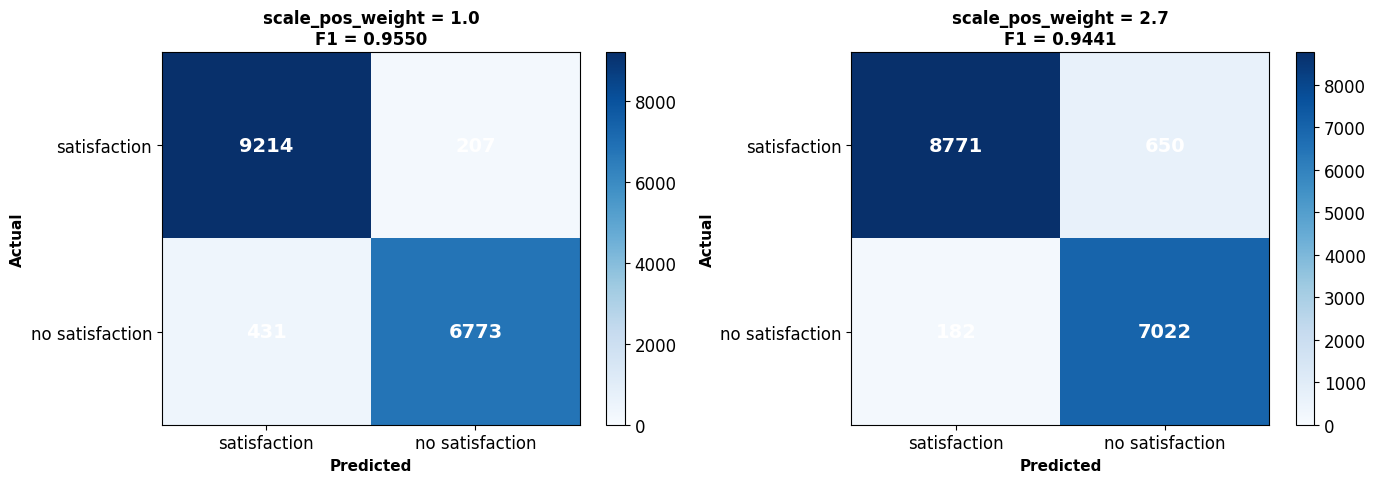

Confusion matrix heatmaps plotted successfully!


In [42]:
# Visualize confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spw_values = [1.0, 2.7]

for idx, spw in enumerate(spw_values):
    # Get confusion matrix values
    tn = scale_pos_weight_results[spw]['tn']
    fp = scale_pos_weight_results[spw]['fp']
    fn = scale_pos_weight_results[spw]['fn']
    tp = scale_pos_weight_results[spw]['tp']
    
    # Create confusion matrix array
    cm_array = np.array([[tn, fp], [fn, tp]])
    
    # Plot heatmap
    ax = axes[idx]
    im = ax.imshow(cm_array, cmap='Blues', aspect='auto', vmin=0)
    
    # Add text annotations
    ax.text(0, 0, f'{tn}', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
    ax.text(1, 0, f'{fp}', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
    ax.text(0, 1, f'{fn}', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
    ax.text(1, 1, f'{tp}', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
    
    # Set labels and title
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['satisfaction', 'no satisfaction'])
    ax.set_yticklabels(['satisfaction', 'no satisfaction'])
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    
    f1 = scale_pos_weight_results[spw]['f1']
    ax.set_title(f'scale_pos_weight = {spw}\nF1 = {f1:.4f}', fontsize=12, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('scale_pos_weight_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("Confusion matrix heatmaps plotted successfully!")